In [14]:
def find_best_sarimax_order(ts, train_end_date, full_series):
    best_mape = np.inf
    best_order = None
    best_seasonal_order = None

    ts = ts.dropna()

    # ADF testi
    try:
        adf_pvalue = adfuller(ts)[1]
        d = 0 if adf_pvalue < 0.05 else 1
    except:
        d = 0

    # ACF testi
    try:
        acf_values = acf(ts, nlags=24)
        if len(acf_values) > 12 and acf_values[12] > 0.3:
            seasonal = True
            s = 12
        else:
            seasonal = False
            s = 0
    except:
        seasonal = False
        s = 0

    for p in range(0, 3):
        for q in range(0, 3):
            try:
                if seasonal:
                    seasonal_order = (1,0,1,s)
                else:
                    seasonal_order = (0,0,0,0)

                model = SARIMAX(ts, order=(p,d,q), seasonal_order=seasonal_order,
                                enforce_stationarity=False, enforce_invertibility=False)
                results = model.fit(disp=False)

                forecast = results.get_forecast(steps=7)
                forecast_mean = forecast.predicted_mean

                test_data = full_series.loc[train_end_date:]
                common_months = test_data.index.intersection(forecast_mean.index)

                if len(common_months) == 0:
                    continue

                actual = test_data.loc[common_months]
                predicted = forecast_mean.loc[common_months]

                mape = mean_absolute_percentage_error(actual, predicted) * 100

                if mape < best_mape:
                    best_mape = mape
                    best_order = (p,d,q)
                    best_seasonal_order = seasonal_order

            except:
                continue

    if best_order is None:
        best_order = (1,0,1)
        best_seasonal_order = (0,0,0,0)
        best_mape = np.nan

    return best_order, best_seasonal_order, best_mape


/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Grade 'A' için seçilen SARIMAX order (MAPE bazlı): (2, 0, 2), seasonal_order: (0, 0, 0, 0), MAPE: 23.02%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:               SARIMAX(2, 0, 2)   Log Likelihood                -324.200
Date:                Sat, 10 May 2025   AIC                            658.400
Time:                        22:22:35   BIC                            665.237
Sample:                    01-01-2022   HQIC                           660.541
                         - 05-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3275      0.141      2.328      0.020       0.052       0.603
ar.L2          0.6679     

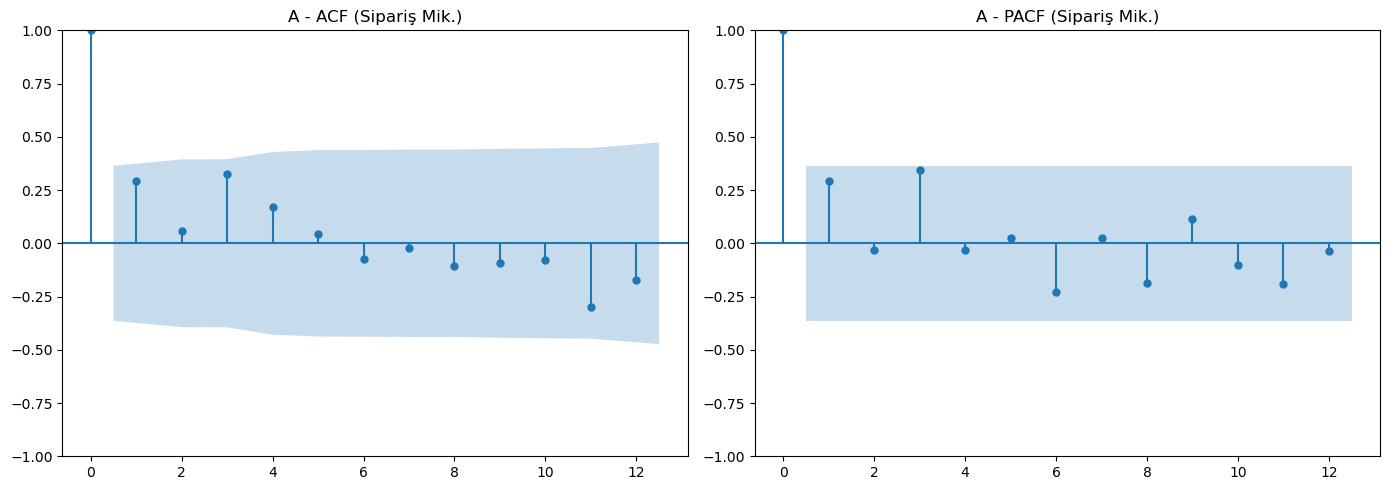

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'A' için MODEL tahmini:
Gerçek: [64860.854 43755.144 57526.535 63912.344 62117.057 45925.374 30077.291], Tahmin: [50911.41406835 51662.28884196 50923.62708503 51183.28670604
 50774.92902247 50814.64559593 50554.89013171]
MAE: 11128.22, MAPE: 23.99%
Grade 'B' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: 81.48%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:               SARIMAX(0, 0, 1)   Log Likelihood                -212.941
Date:                Sat, 10 May 2025   AIC                            429.881
Time:                        22:22:37   BIC                            432.616
Sample:                    01-01-2022   HQIC                    

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


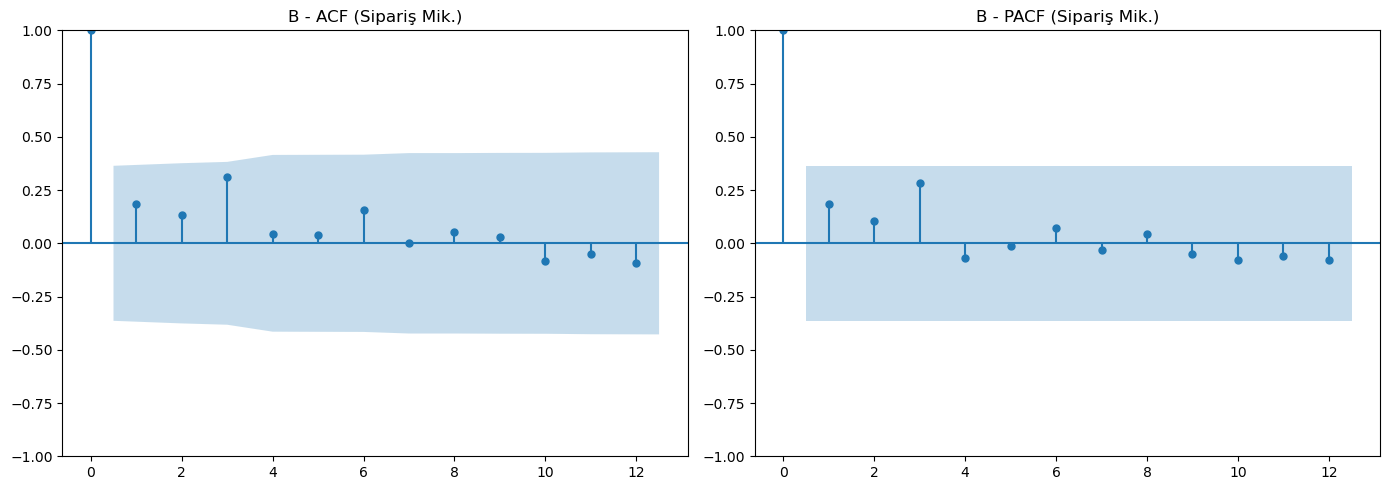

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'B' için MODEL tahmini:
Gerçek: [140.   168.02   0.   285.68  65.09 329.69  96.31], Tahmin: [50.47083768  0.          0.          0.          0.          0.
  0.        ]
MAE: 147.76, MAPE: 80.56%
Grade 'C' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 42.86%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -235.824
Date:                Sat, 10 May 2025   AIC                            473.647
Time:                        22:22:37   BIC                            475.014
Sample:                    01-01-2022   HQIC                           474.075
                         - 05-01-2024

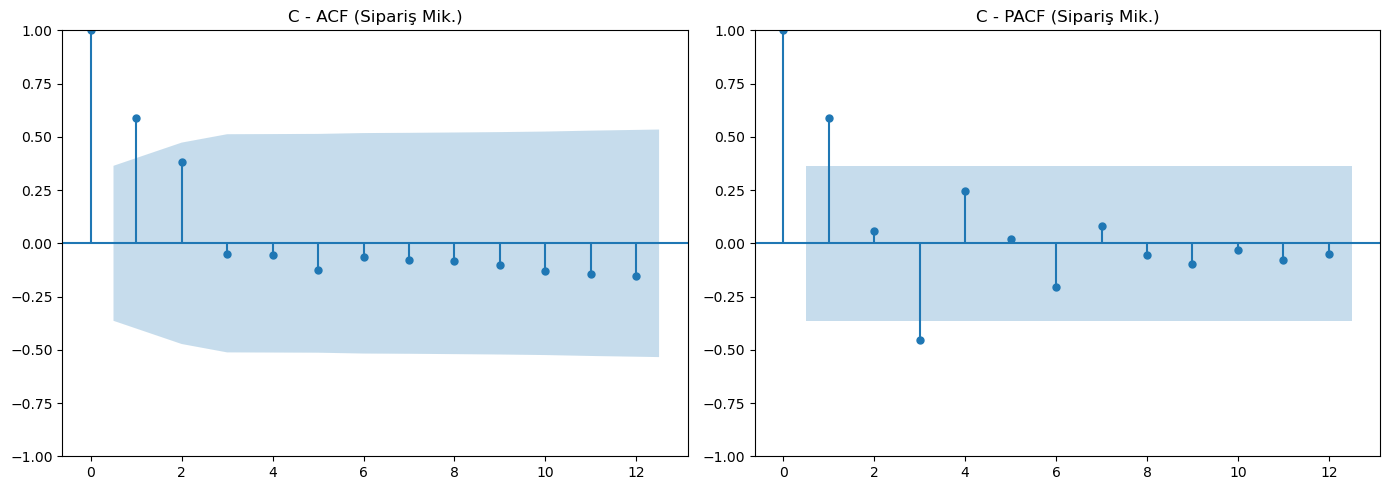

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'C' için MODEL tahmini:
Gerçek: [126.96  61.    37.06   0.     0.     0.     0.  ], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 32.15, MAPE: 42.86%
Grade 'D' için seçilen SARIMAX order (MAPE bazlı): (2, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 83.44%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:               SARIMAX(2, 0, 0)   Log Likelihood                -254.076
Date:                Sat, 10 May 2025   AIC                            514.152
Time:                        22:22:38   BIC                            518.254
Sample:                    01-01-2022   HQIC                           515.436
                         - 05-01-2024                                         
Covariance Type

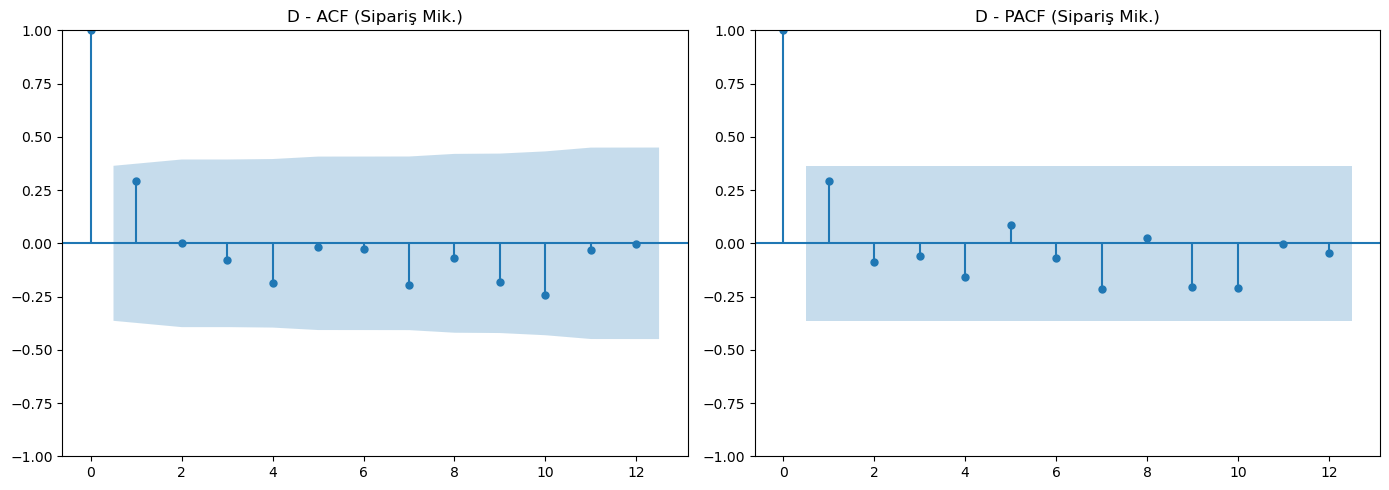

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'D' için MODEL tahmini:
Gerçek: [ 228.    1967.    2681.78   440.    6098.069 2875.    1064.   ], Tahmin: [413.56792772 344.06081079 269.04964247 213.92242191 169.31907578
 134.18144867 106.29989217]
MAE: 2010.65, MAPE: 83.97%
Grade 'DD11' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 14.29%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -284.567
Date:                Sat, 10 May 2025   AIC                            571.134
Time:                        22:22:38   BIC                            572.502
Sample:                    01-01-2022   HQIC                           571.563
    

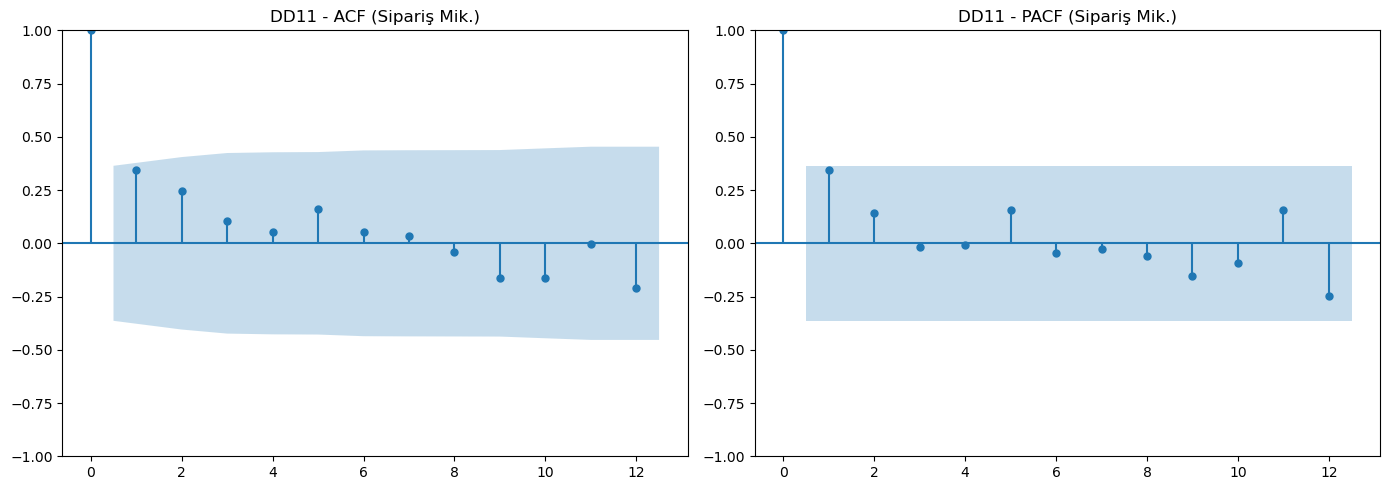

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'DD11' için MODEL tahmini:
Gerçek: [ 0.    0.    0.    0.   39.84  0.    0.  ], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 5.69, MAPE: 14.29%
Grade 'DD11-1' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -312.035
Date:                Sat, 10 May 2025   AIC                            626.069
Time:                        22:22:39   BIC                            627.437
Sample:                    01-01-2022   HQIC                           626.497
                         - 05-01-2024                                         
Covariance Type:

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


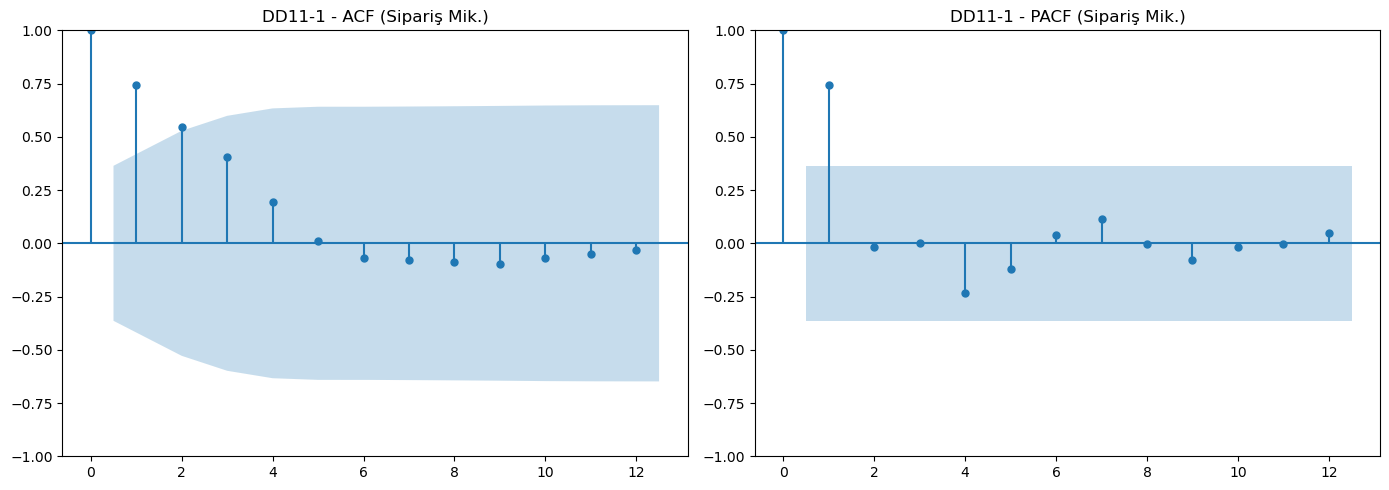

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'DD11-1' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
DD11-1 için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-1 için 2024-08 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-1 için 2024-09 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-1 için 2024-11 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'DD11-2' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -251.601
Date:           

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


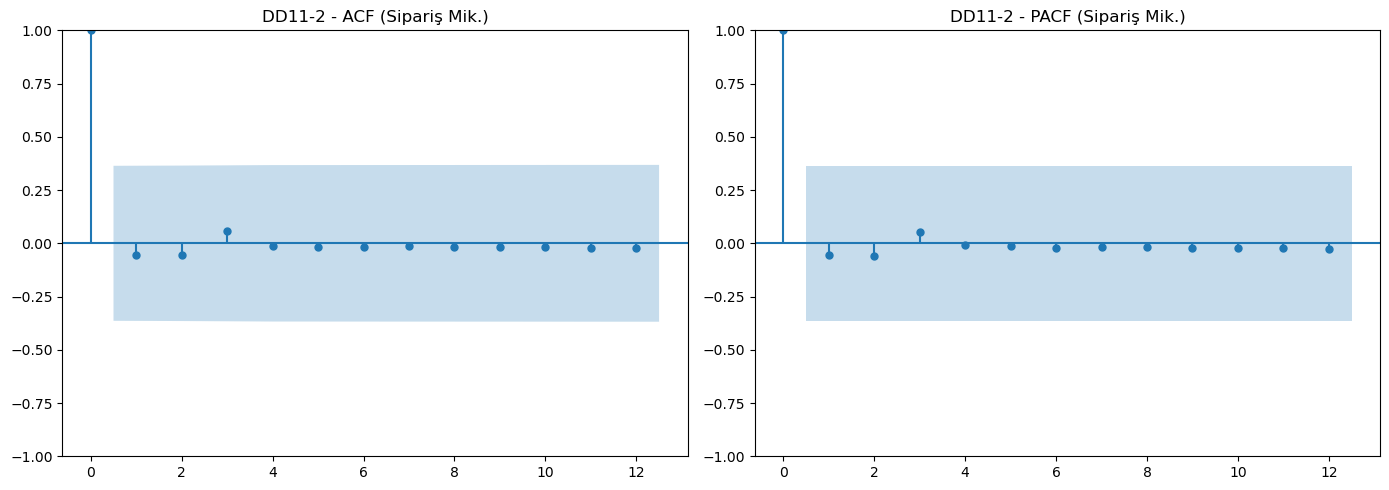

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'DD11-2' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
DD11-2 için 2024-06 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-2 için 2024-08 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-2 için 2024-09 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-2 için 2024-10 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'DD13' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -181.546
Date:             

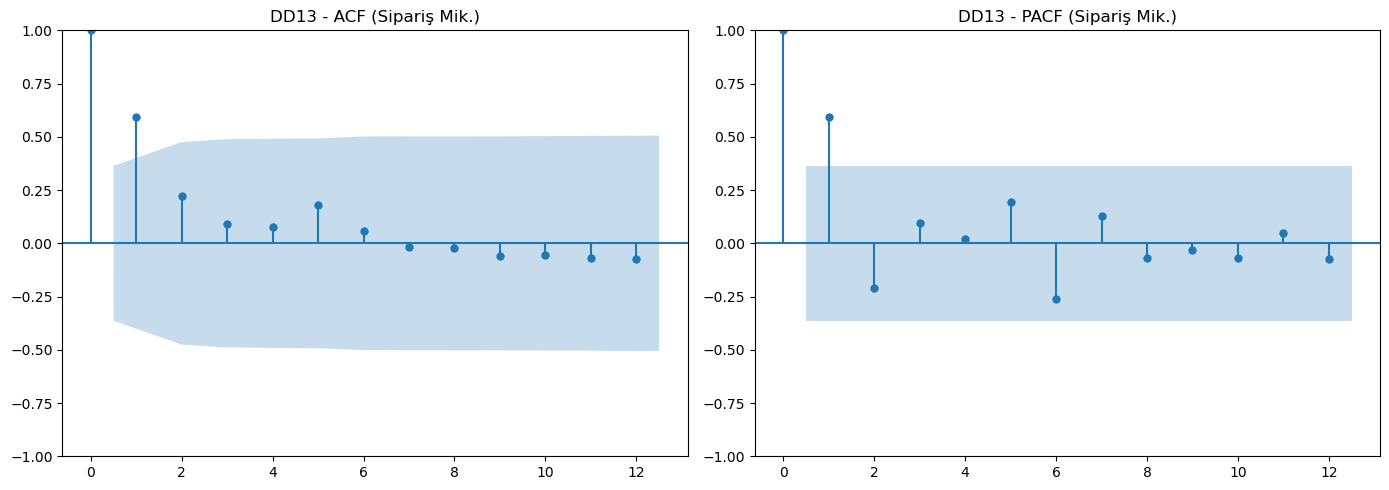

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'DD13' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
DD13 için 2024-12 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'E' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 42.86%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -208.129
Date:                Sat, 10 May 2025   AIC                            418.258
Time:                        22:22:40   BIC                            419.625
Sample:                    01-01-2022   HQIC                           418.686
                         - 05-01-2024  

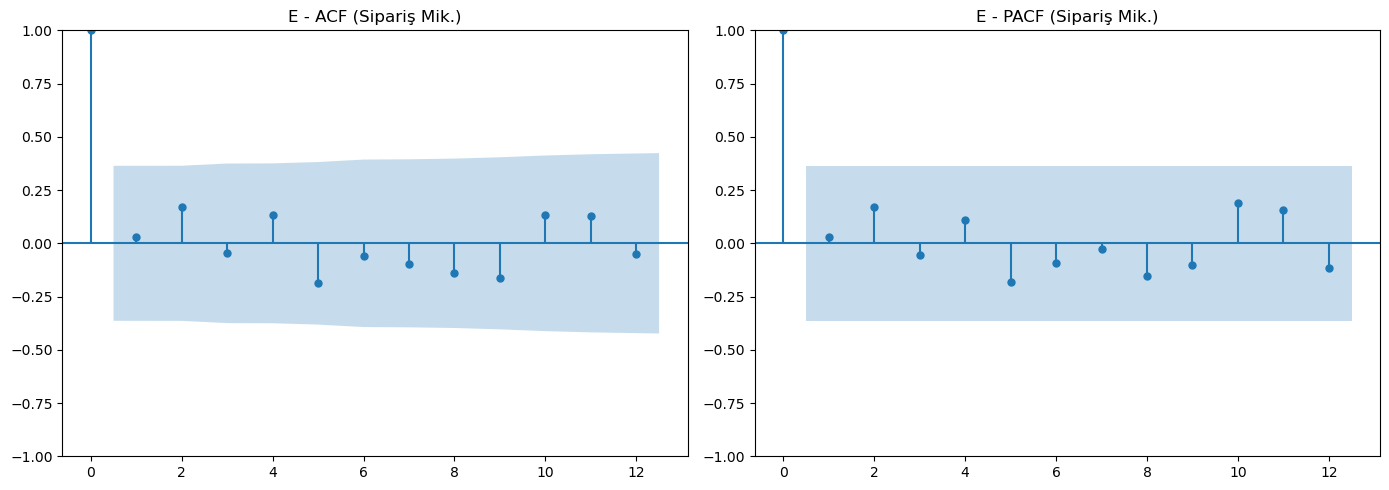

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'E' için MODEL tahmini:
Gerçek: [  0.     0.     0.     0.     3.44  23.18 173.04], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 28.52, MAPE: 42.86%
E için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'P265NB' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -205.739
Date:                Sat, 10 May 2025   AIC                            413.478
Time:                        22:22:40   BIC                            414.845
Sample:                    01-01-2022   HQIC                           413.906
           

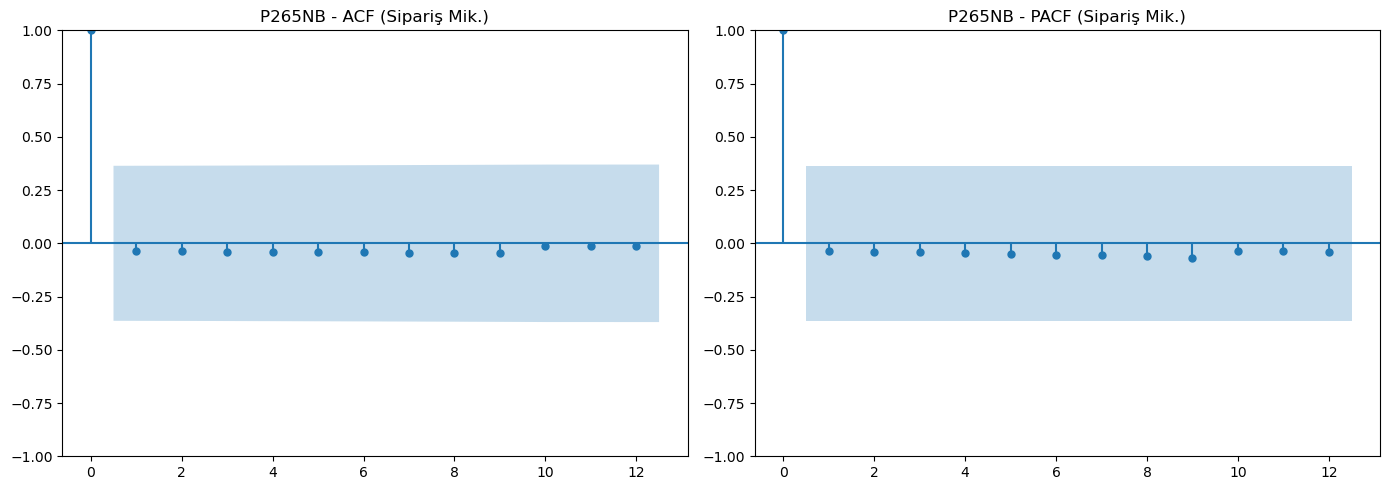

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'P265NB' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
P265NB için 2024-06 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2024-08 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2024-09 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2024-11 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2024-12 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'S235JR' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 14.29%
                               SARIMAX Results                                
Dep. 

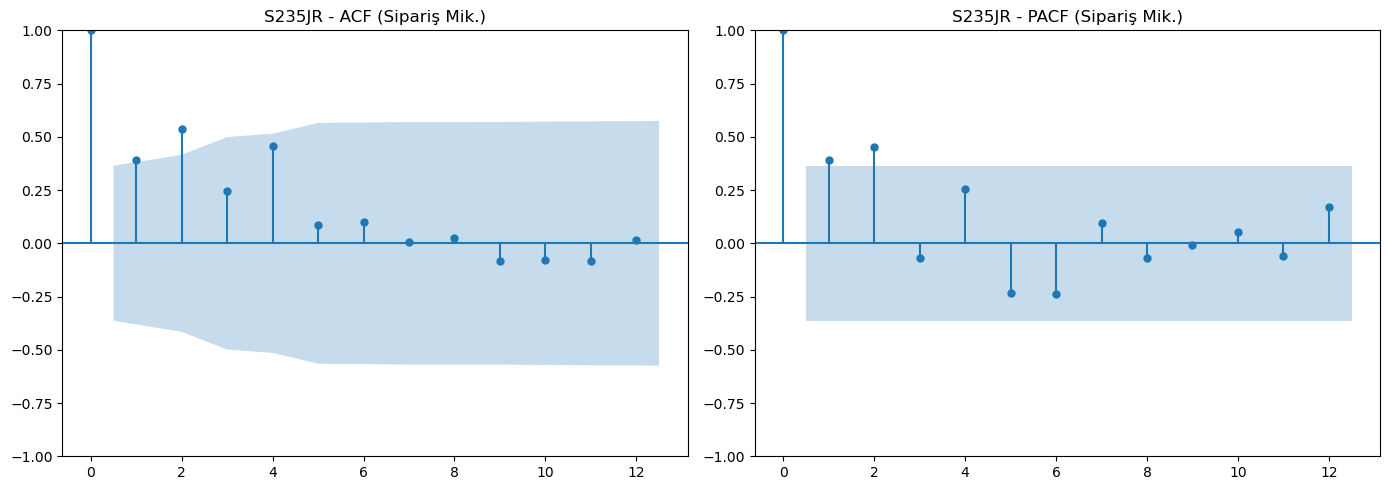

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'S235JR' için MODEL tahmini:
Gerçek: [  0.     0.     0.     0.   109.81   0.     0.  ], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 15.69, MAPE: 14.29%
Grade 'S235JR-1' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 14.29%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -261.002
Date:                Sat, 10 May 2025   AIC                            524.005
Time:                        22:22:42   BIC                            525.372
Sample:                    01-01-2022   HQIC                           524.433
                         - 05-01-2024                                         
Cov

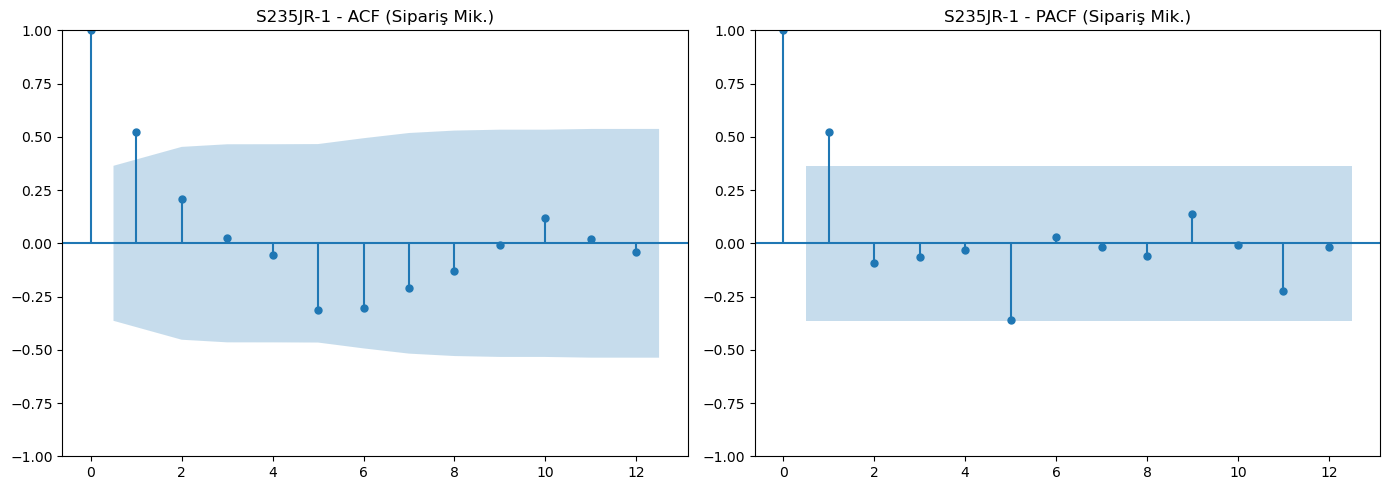

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'S235JR-1' için MODEL tahmini:
Gerçek: [ 0.    0.    0.    0.   20.91  0.    0.  ], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 2.99, MAPE: 14.29%


/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grade 'S235JR-CL3' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -180.156
Date:                Sat, 10 May 2025   AIC                            362.311
Time:                        22:22:42   BIC                            363.679
Sample:                    01-01-2022   HQIC                           362.739
                         - 05-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1.457e+04   1189.560     12.247      0.000    1.22e+04    1.69e+04
Ljung-Box (L1) (Q)

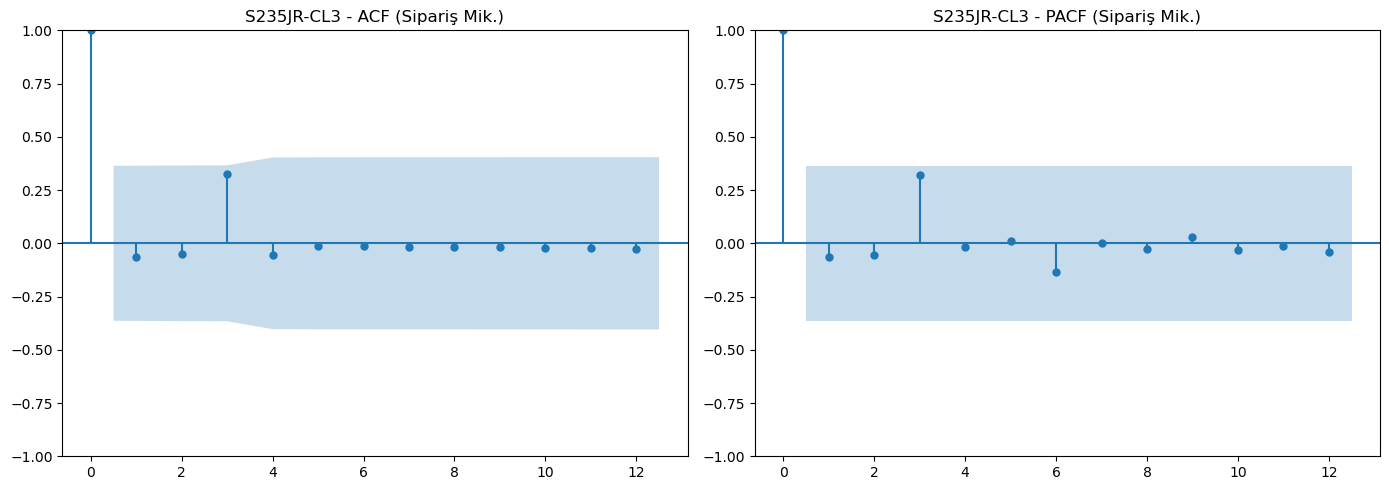

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'S235JR-CL3' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
S235JR-CL3 için 2024-06 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2024-08 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2024-09 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2024-10 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2024-11 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2024-12 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'S275J2' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_or

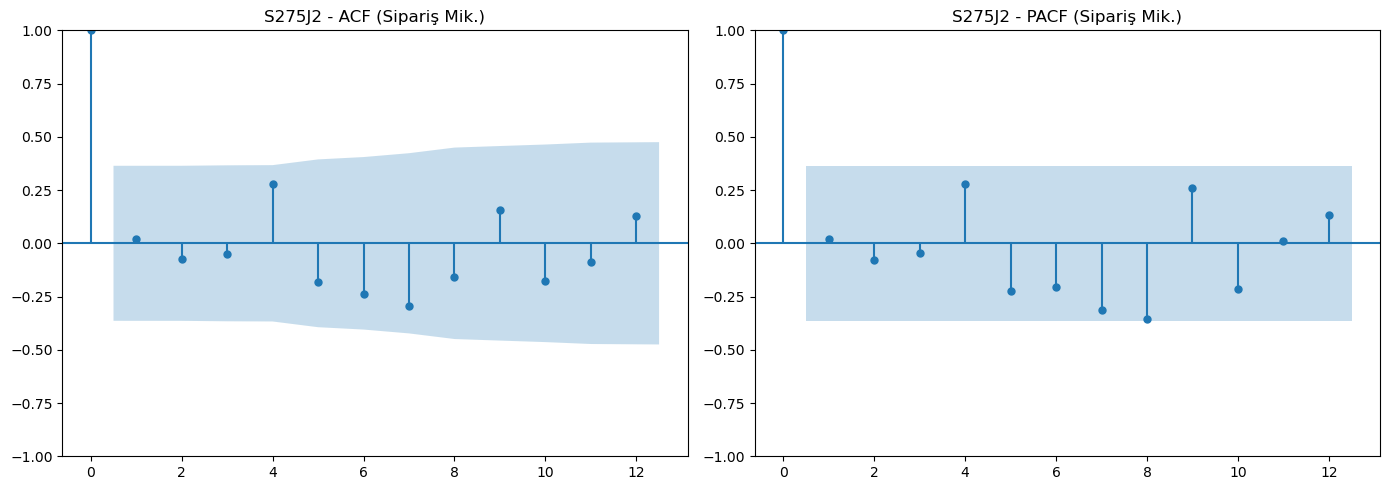

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'S275J2' için MODEL tahmini:
Gerçek: [  0.   0. 108.   0.   0.   0. 120.], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 32.57, MAPE: 28.57%
S275J2 için 2024-11 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'S275JR' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -213.521
Date:                Sat, 10 May 2025   AIC                            429.041
Time:                        22:22:43   BIC                            430.409
Sample:                    01-01-2022   HQIC                           429.469
               

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


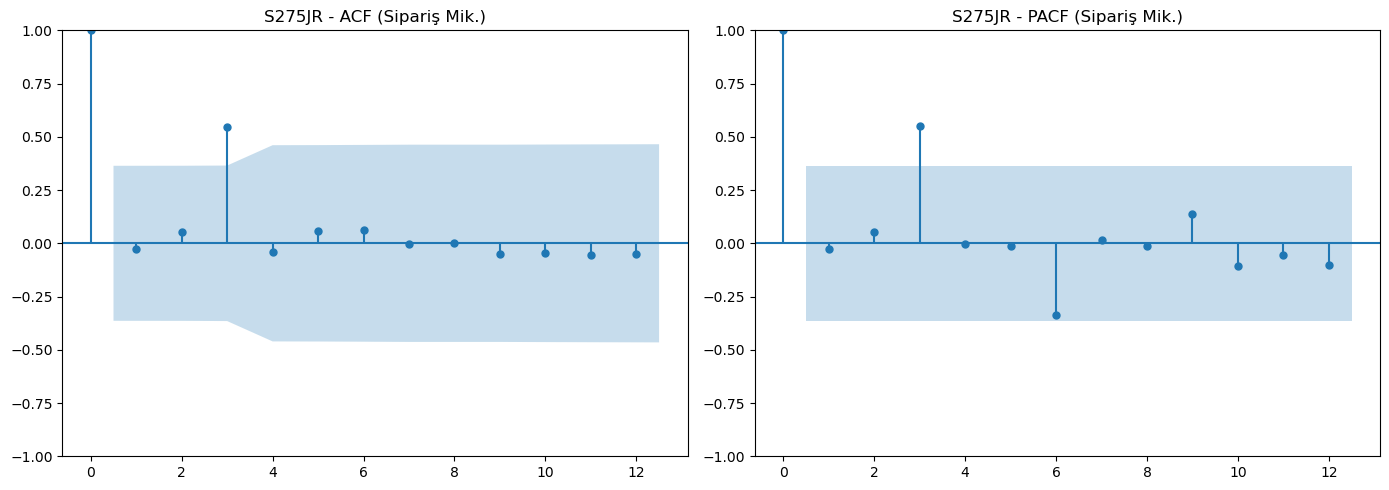

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'S275JR' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
S275JR için 2024-06 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S275JR için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S275JR için 2024-11 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S275JR için 2024-12 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.


/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grade 'S355J2' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -173.587
Date:                Sat, 10 May 2025   AIC                            349.174
Time:                        22:22:44   BIC                            350.541
Sample:                    01-01-2022   HQIC                           349.602
                         - 05-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      9261.6986   1131.964      8.182      0.000    7043.090    1.15e+04
Ljung-Box (L1) (Q):   

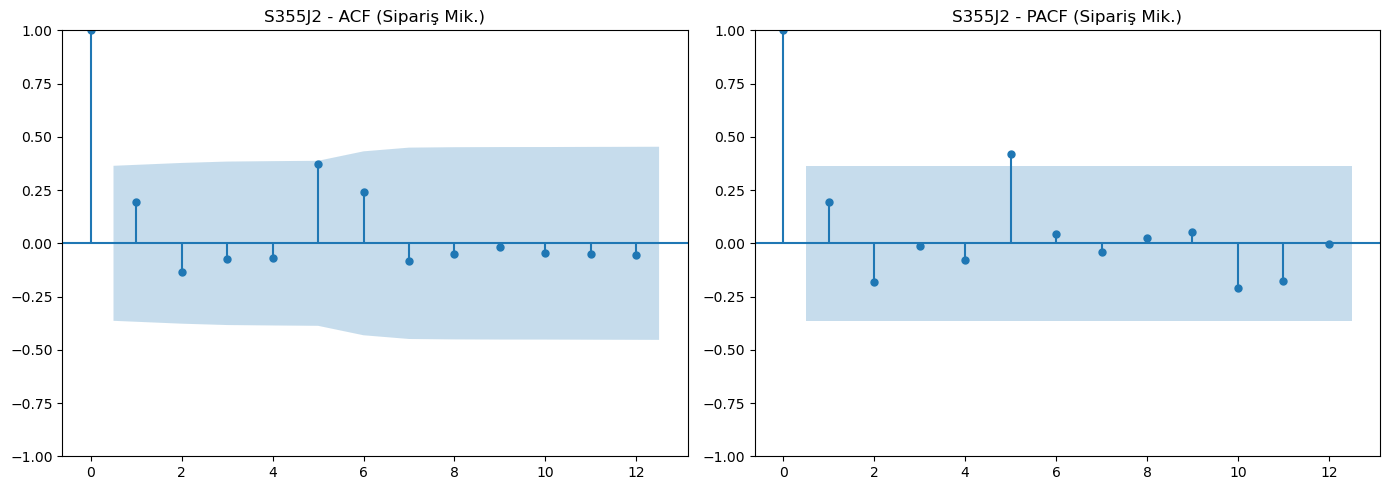

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

📈 Grade 'S355J2' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
S355J2 için 2024-06 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S355J2 için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S355J2 için 2024-08 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S355J2 için 2024-11 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.


In [15]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:,.2f}'.format

# 1. Veri yükleme
df = pd.read_excel('../preprocessedBelgeler/mapped_zero_filled_forecastData_altLimit100_son3_byGrup.xlsx')  # Dosya adını değiştir
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# 2. Aylık grade bazlı toplam sipariş
monthly_grade = df.groupby(['Month', 'Grade'])['Sipariş Mik. (TON)'].sum().reset_index()
grade_list = monthly_grade['Grade'].unique()

# Tahminler ve dağıtılmış sonuçlar için boş dataframe
forecast_df = pd.DataFrame()
train_forecast_df = pd.DataFrame()
disaggregated_df = pd.DataFrame()
disaggregated_forecast_df = pd.DataFrame()


mae_list = []
mape_list = []

sarimax_param_log = []

# 3. Her grade için SARIMAX modeli ile tahmin
for grade in grade_list:
    # 1. Grade'e ait zaman serisini hazırla
    grade_data = monthly_grade[monthly_grade['Grade'] == grade].set_index('Month')
    
    # 🔒 Model verisini 2018-01 ile 2024-12 arasında sınırla
    grade_data = grade_data.loc['2022-01':'2024-5']

    grade_ts = grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
    
    # 2. ❗ Sabit ya da boş seri kontrolü
    if grade_ts.std() < 1e-3 or grade_ts.sum() == 0:
        print(f"'{grade}' atlandı çünkü zaman serisi sabit veya boş.")
        continue  # bu grade'i atla

   

    # 3. SARIMAX Modeli
    try:
        # 🔥 Grade'e özel en iyi order'ı, seasonal order'ı ve best_mape'i bul
        full_grade_data = monthly_grade[monthly_grade['Grade'] == grade].set_index('Month')  # full series data çekiyoruz
        full_grade_data = full_grade_data.loc['2022-01':'2024-12']  # geçmiş+gelecek tüm veri

        best_order, best_seasonal_order, best_mape = find_best_sarimax_order(
            grade_ts, 
            train_end_date='2024-06-01', 
            full_series=full_grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
        )

        print(f"Grade '{grade}' için seçilen SARIMAX order (MAPE bazlı): {best_order}, seasonal_order: {best_seasonal_order}, MAPE: {best_mape:.2f}%")

        # 🔥 SARIMAX Modeli kur
        model = SARIMAX(grade_ts, order=best_order, seasonal_order=best_seasonal_order)
        results = model.fit(disp=False)
        print(results.summary())
        # 🔥 Logla
        sarimax_param_log.append({
            'Grade': grade,
            'Order': best_order,
            'Seasonal_Order': best_seasonal_order,
            'MAPE (%)': round(best_mape, 2)
        })



    except Exception as e:
        print(f"{grade} için model kurulamadı: {e}")
        continue

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(grade_ts, lags=12, ax=ax[0])
    ax[0].set_title(f"{grade} - ACF (Sipariş Mik.)")
    
    plot_pacf(grade_ts, lags=12, ax=ax[1], method='ywm')  # 'ywm' daha stabil PACF için
    ax[1].set_title(f"{grade} - PACF (Sipariş Mik.)")

    plt.tight_layout()
    plt.show()
    
    # 4. Tahmin (örnek: 7 ay ileri)
    forecast = results.get_forecast(steps=7)
    forecast_values = forecast.predicted_mean
    forecast_index = forecast_values.index
    
    train_forecast = results.predict(start=grade_ts.index[0], end=grade_ts.index[-1])
    train_forecast_index = train_forecast.index
    
    # 🔍 Gerçek 2025 verisini al
    full_grade_data = monthly_grade[monthly_grade['Grade'] == grade].set_index('Month')
    test_data = full_grade_data.loc['2024-06':'2024-12']['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
    common_months = test_data.index.intersection(forecast_index)

    print(common_months)
    if len(common_months) > 0:
        actual = test_data.loc[common_months]
        predicted = forecast_values.loc[common_months]

        mae = mean_absolute_error(actual, predicted)
        mape = mean_absolute_percentage_error(actual, predicted)

        mae_list.append({'Grade': grade, 'MAE_Model': mae})
        mape_list.append({'Grade': grade, 'MAPE_Model': mape})

        print(f"\n📈 Grade '{grade}' için MODEL tahmini:")
        print(f"Gerçek: {actual.values}, Tahmin: {predicted.values}")
        print(f"MAE: {mae:.2f}, MAPE: {mape:.2%}")

    # 5. Forecast DataFrame'e ekle
    temp_forecast = pd.DataFrame({
        'Month': forecast_index,
        'Grade': grade,
        'Forecast_TON': forecast_values.values
    })
    forecast_df = pd.concat([forecast_df, temp_forecast], ignore_index=True)
    
    temp_forecast_train = pd.DataFrame({
        'Month': train_forecast_index,
        'Grade': grade,
        'Forecast_TON': train_forecast.values
    })
    train_forecast_df = pd.concat([train_forecast_df, temp_forecast_train], ignore_index=True)
    
    # 6. Disaggregation (her tahmin edilen ayı specGroupId'lere dağıt)
    for month in forecast_index:
        # Önce o grade'in geçmiş aynı aya ait oranlarını bul
        past_months = df[(df['Grade'] == grade) & (df['Month'].dt.month == month.month)]
        past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
        total = past_months_total.sum()
        

        # Eğer ay bazlı veri yoksa: tüm geçmişi fallback olarak kullan
        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.")
            past_months = df[df['Grade'] == grade]
            past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            total = past_months_total.sum()

        # Hâlâ yoksa atla
        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında hiçbir geçmiş veri bulunamadı.")
            continue

        proportions = past_months_total / total
        disagg = proportions * forecast_values[month]

        for spec_id, miktar in disagg.items():
            disaggregated_df = pd.concat([disaggregated_df, pd.DataFrame({
                'Month': [month],
                'Grade': [grade],
                'SpecGroupId': [spec_id],
                'Forecast_TON': [miktar]
            })])
        
        

        # 💡 SpecGroupId bazlı gerçek değerlerle kıyasla
        actual_df = df[(df['Month'] == month) & (df['Grade'] == grade)]
        actual_agg = actual_df.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()

        forecast_agg = disaggregated_df[
            (disaggregated_df['Month'] == month) &
            (disaggregated_df['Grade'] == grade)
        ].groupby('SpecGroupId')['Forecast_TON'].sum()

        common_index = actual_agg.index.intersection(forecast_agg.index)

        if len(common_index) > 0:
            actual_vals = actual_agg.loc[common_index]
            pred_vals = forecast_agg.loc[common_index]

            mae_spec = mean_absolute_error(actual_vals, pred_vals)
            mape_spec = mean_absolute_percentage_error(actual_vals, pred_vals)

            # 🔁 Sonuçları listeye ekle
            for spec_id in common_index:
                disagg_metrics = {
                    'Grade': grade,
                    'Month': month,
                    'SpecGroupId': spec_id,
                    'MAE_Disagg': abs(actual_vals[spec_id] - pred_vals[spec_id]),
                    'MAPE_Disagg': abs((actual_vals[spec_id] - pred_vals[spec_id]) / actual_vals[spec_id]) if actual_vals[spec_id] != 0 else np.nan
                }
                mae_list.append(disagg_metrics)

               
        """   
        #OVERFIT TEST
        # 6. Disaggregation for train

                
        for forecast_month in train_forecast_index:
            # Try to get proportions based on same calendar month in history
            historical_month_data = df[(df['Grade'] == grade) & 
                                            (df['Month'].dt.month == forecast_month.month)]

            monthly_group_totals = historical_month_data.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            monthly_total_sum = monthly_group_totals.sum()
            spec_30_total = monthly_group_totals.get(30, 0)
            print(forecast_month,spec_30_total)

            # If no month-based data, fallback to all historical data for the grade
            if monthly_total_sum == 0:
                print(f"{grade} için {forecast_month.strftime('%Y-%m')} ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.")
                historical_month_data = df[df['Grade'] == grade]
                monthly_group_totals = historical_month_data.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
                monthly_total_sum = monthly_group_totals.sum()

            # Still no data? Skip.
            if monthly_total_sum == 0:
                print(f"{grade} için {forecast_month.strftime('%Y-%m')} ayında hiçbir geçmiş veri bulunamadı.")
                continue

            spec_group_proportions = monthly_group_totals / monthly_total_sum
            disaggregated_values = spec_group_proportions * train_forecast[forecast_month]


            spec_30 = spec_group_proportions.get(30, 0)
            print("specgroupproop",spec_30)
            print("alttaki",train_forecast)

            for spec_group_id, forecast_ton in disaggregated_values.items():
                disaggregated_forecast_df = pd.concat([disaggregated_forecast_df, pd.DataFrame({
                    'Month': [forecast_month],
                    'Grade': [grade],
                    'SpecGroupId': [spec_group_id],
                    'Forecast_TON': [forecast_ton]
                })])
            
            
        """
            
    

# İstersen Excel'e aktar:
#disaggregated_df.to_excel("disaggregated_forecast.xlsx", index=False)


In [16]:
params_df = pd.DataFrame(sarimax_param_log)
print("\n📋 Grade Bazlı SARIMAX Parametreleri ve MAPE Skorları:")
print(params_df.sort_values(by='MAPE (%)').reset_index(drop=True))

# (İstersen Excel'e aktar)
# params_df.to_excel("sarimax_parametreleri_mape.xlsx", index=False)




📋 Grade Bazlı SARIMAX Parametreleri ve MAPE Skorları:
         Grade      Order Seasonal_Order  MAPE (%)
0       DD11-1  (0, 0, 0)   (0, 0, 0, 0)      0.00
1       DD11-2  (0, 0, 0)   (0, 0, 0, 0)      0.00
2         DD13  (0, 0, 0)   (0, 0, 0, 0)      0.00
3       P265NB  (0, 0, 0)   (0, 0, 0, 0)      0.00
4   S235JR-CL3  (0, 0, 0)   (0, 0, 0, 0)      0.00
5       S275JR  (0, 0, 0)   (0, 0, 0, 0)      0.00
6       S355J2  (0, 0, 0)   (0, 0, 0, 0)      0.00
7         DD11  (0, 0, 0)   (0, 0, 0, 0)     14.29
8       S235JR  (0, 0, 0)   (0, 0, 0, 0)     14.29
9     S235JR-1  (0, 0, 0)   (0, 0, 0, 0)     14.29
10           A  (2, 0, 2)   (0, 0, 0, 0)     23.02
11      S275J2  (0, 0, 0)   (0, 0, 0, 0)     28.57
12           C  (0, 0, 0)   (0, 0, 0, 0)     42.86
13           E  (0, 0, 0)   (0, 0, 0, 0)     42.86
14           B  (0, 0, 1)   (0, 0, 0, 0)     81.48
15           D  (2, 0, 0)   (0, 0, 0, 0)     83.44


In [17]:
from sklearn.metrics import mean_squared_error

# 🎯 Grade bazlı performans metriklerini hesapla
grade_metrics = []

# forecast_df: grade bazlı 3 aylık tahminlerin olduğu dataframe
# monthly_grade: gerçek değerlerin olduğu dataframe

for grade in forecast_df['Grade'].unique():
    # Tahmin edilen veriler
    pred_series = forecast_df[forecast_df['Grade'] == grade].set_index('Month')['Forecast_TON']
    
    # Gerçek veriler
    actual_series = monthly_grade[monthly_grade['Grade'] == grade].set_index('Month')['Sipariş Mik. (TON)']
    
    # Ortak aylar
    common_months = pred_series.index.intersection(actual_series.index)
    
    if len(common_months) == 0:
        continue

    y_true = actual_series.loc[common_months]
    y_pred = pred_series.loc[common_months]

    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

    grade_metrics.append({
        'Grade': grade,
        'MAE': mae,
        'MAPE (%)': mape,
        'sMAPE (%)': smape,
        'wMAPE (%)': wmape,
        'RMSE': rmse
    })

# 🎉 Sonuçları tablo olarak göster
grade_metrics_df = pd.DataFrame(grade_metrics)
print("\n📊 Grade Bazlı Tahmin Performansı:")
print(grade_metrics_df)

# Excel'e kaydetmek istersen:
# grade_metrics_df.to_excel("grade_metrics_summary.xlsx", index=False)



📊 Grade Bazlı Tahmin Performansı:
         Grade       MAE  MAPE (%)  sMAPE (%)  wMAPE (%)      RMSE
0            A 11,128.22     23.99      22.28      21.16 12,157.41
1            B    147.76     80.56     182.33      95.35    185.19
2            C     32.15     42.86     200.00     100.00     55.05
3            D  2,010.65     83.97     138.00      91.67  2,728.69
4         DD11      5.69     14.29     200.00     100.00     15.06
5       DD11-1      0.00      0.00        NaN        NaN      0.00
6       DD11-2      0.00      0.00        NaN        NaN      0.00
7         DD13      0.00      0.00        NaN        NaN      0.00
8            E     28.52     42.86     200.00     100.00     66.00
9       P265NB      0.00      0.00        NaN        NaN      0.00
10      S235JR     15.69     14.29     200.00     100.00     41.50
11    S235JR-1      2.99     14.29     200.00     100.00      7.90
12  S235JR-CL3      0.00      0.00        NaN        NaN      0.00
13      S275J2     32.57   

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_40751/380144074.py:29: RuntimeWarning: invalid value encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_40751/380144074.py:29: RuntimeWarning: invalid value encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_40751/380144074.py:29: RuntimeWarning: invalid value encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_40751/380144074.py:29: RuntimeWarning: invalid value encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_40751/380144074.py:29: RuntimeWarning: invalid value encountered in double_scalar

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 🎯 Tüm Grade'ler için genel hata metrikleri
# forecast_df: tahminler (2025-01 ~ 2025-03)
# monthly_grade: gerçek değerler

# Gerçek veriyi 2025-01 ile 2025-03 arasından alalım
actual_all = monthly_grade[
    (monthly_grade['Month'] >= '2024-06') & 
    (monthly_grade['Month'] <= '2024-12')
]

# Tahmin edilen veriler zaten forecast_df içinde (her Grade için)
merged_all = pd.merge(
    actual_all, 
    forecast_df, 
    on=['Month', 'Grade'], 
    how='inner'
)

# Boş varsa at
merged_all.dropna(subset=['Sipariş Mik. (TON)', 'Forecast_TON'], inplace=True)
print(merged_all)
# Gerçek ve tahmin serileri
y_true_all = merged_all['Sipariş Mik. (TON)']
y_pred_all = merged_all['Forecast_TON']

# Hata metrikleri
mae_all = mean_absolute_error(y_true_all, y_pred_all)
mape_all = mean_absolute_percentage_error(y_true_all, y_pred_all) * 100
rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
smape_all = 100 * np.mean(2 * np.abs(y_pred_all - y_true_all) / (np.abs(y_true_all) + np.abs(y_pred_all)))
wmape_all = 100 * np.sum(np.abs(y_pred_all - y_true_all)) / np.sum(np.abs(y_true_all))

# 📢 Sonuçları yazdır
print("\n📦 Tüm Grade'ler için TOPLAM tahmin performansı:")
print(f"MAE   : {mae_all:.2f}")
print(f"MAPE  : {mape_all:.2f}%")
print(f"sMAPE : {smape_all:.2f}%")
print(f"wMAPE : {wmape_all:.2f}%")
print(f"RMSE  : {rmse_all:.2f}")


         Month       Grade  Sipariş Mik. (TON)  Forecast_TON
0   2024-06-01           A           64,860.85     50,911.41
1   2024-06-01           B              140.00         50.47
2   2024-06-01           C              126.96          0.00
3   2024-06-01           D              228.00        413.57
4   2024-06-01        DD11                0.00          0.00
..         ...         ...                 ...           ...
107 2024-12-01    S235JR-1                0.00          0.00
108 2024-12-01  S235JR-CL3                0.00          0.00
109 2024-12-01      S275J2              120.00          0.00
110 2024-12-01      S275JR                0.00          0.00
111 2024-12-01      S355J2                0.00          0.00

[112 rows x 4 columns]

📦 Tüm Grade'ler için TOPLAM tahmin performansı:
MAE   : 837.77
MAPE  : 21.60%
sMAPE : 142.45%
wMAPE : 24.34%
RMSE  : 3115.44


⏳ 2024-06 ayı için grafik hazırlanıyor...


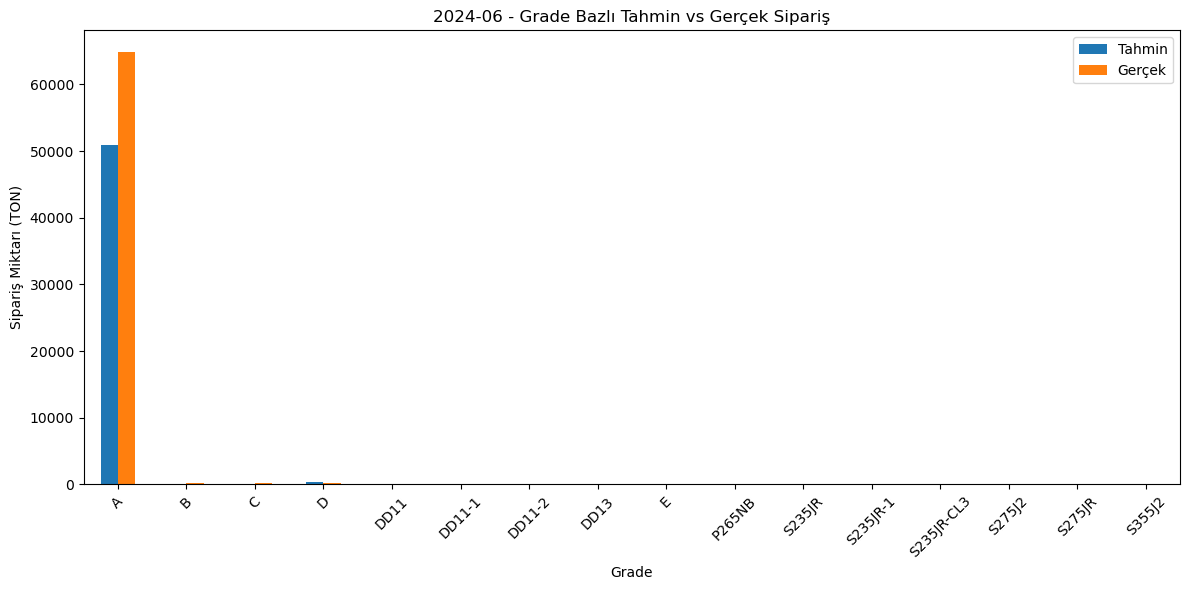

⏳ 2024-07 ayı için grafik hazırlanıyor...


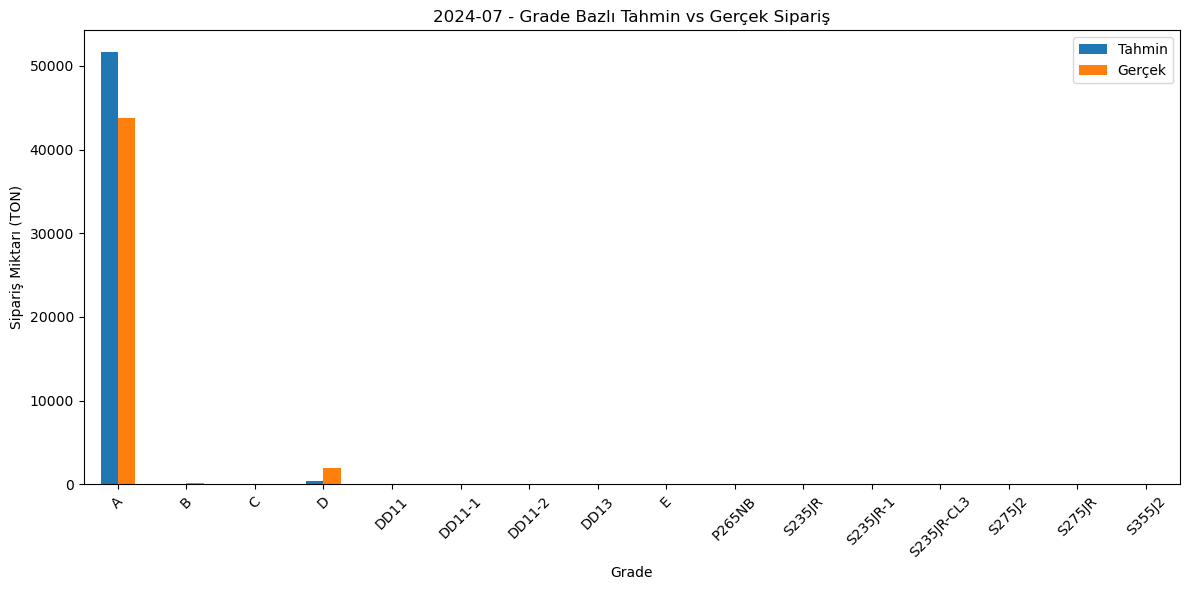

⏳ 2024-08 ayı için grafik hazırlanıyor...


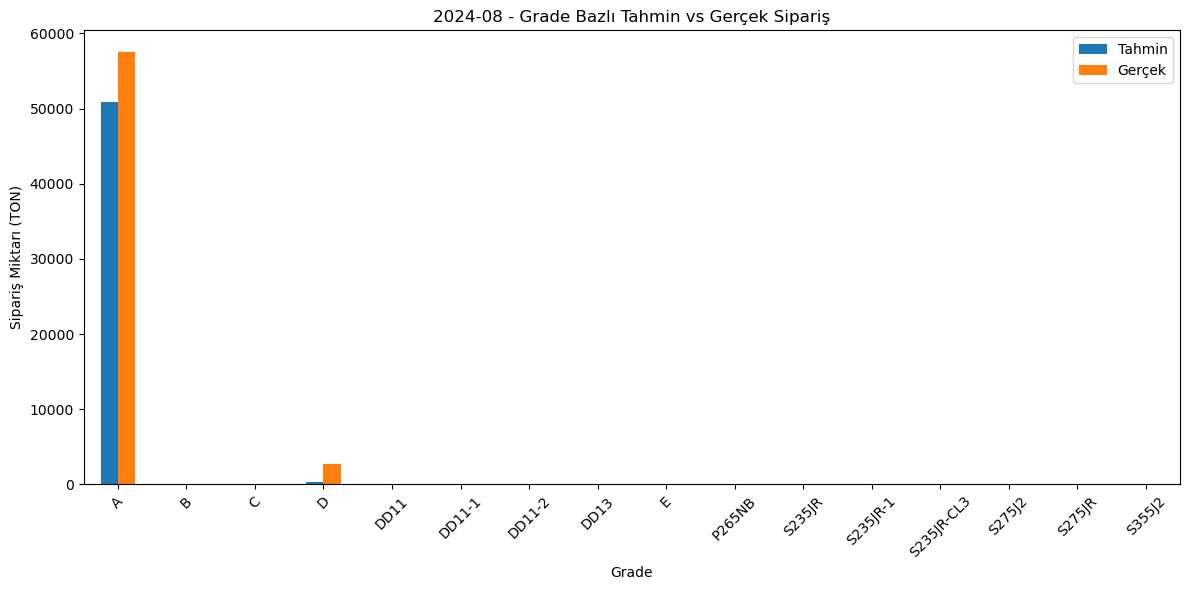

⏳ 2024-09 ayı için grafik hazırlanıyor...


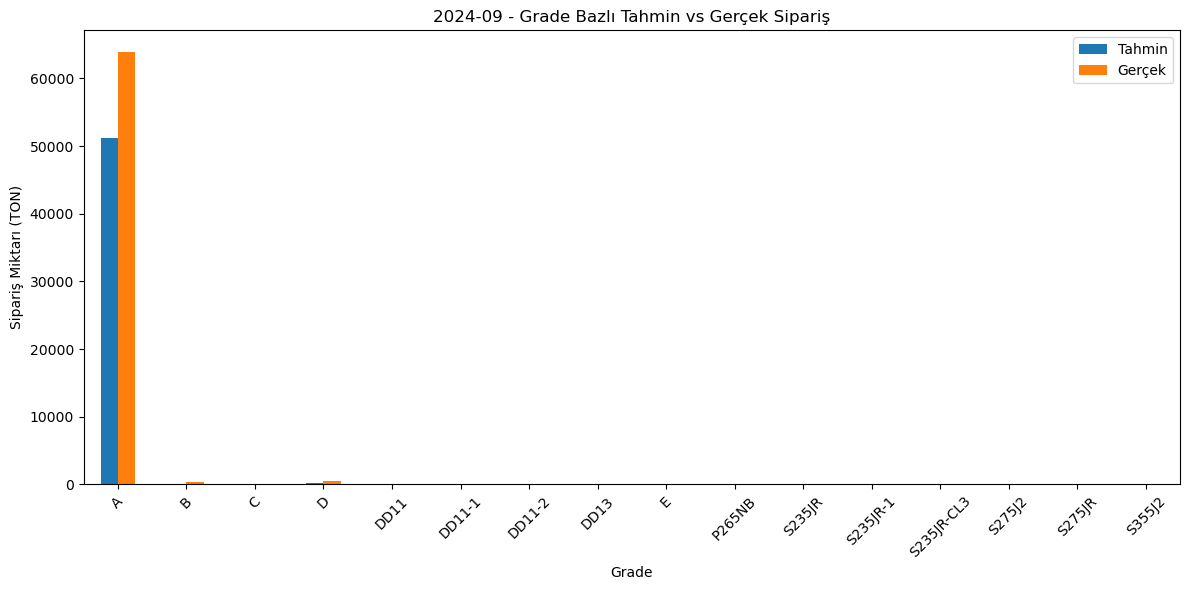

⏳ 2024-10 ayı için grafik hazırlanıyor...


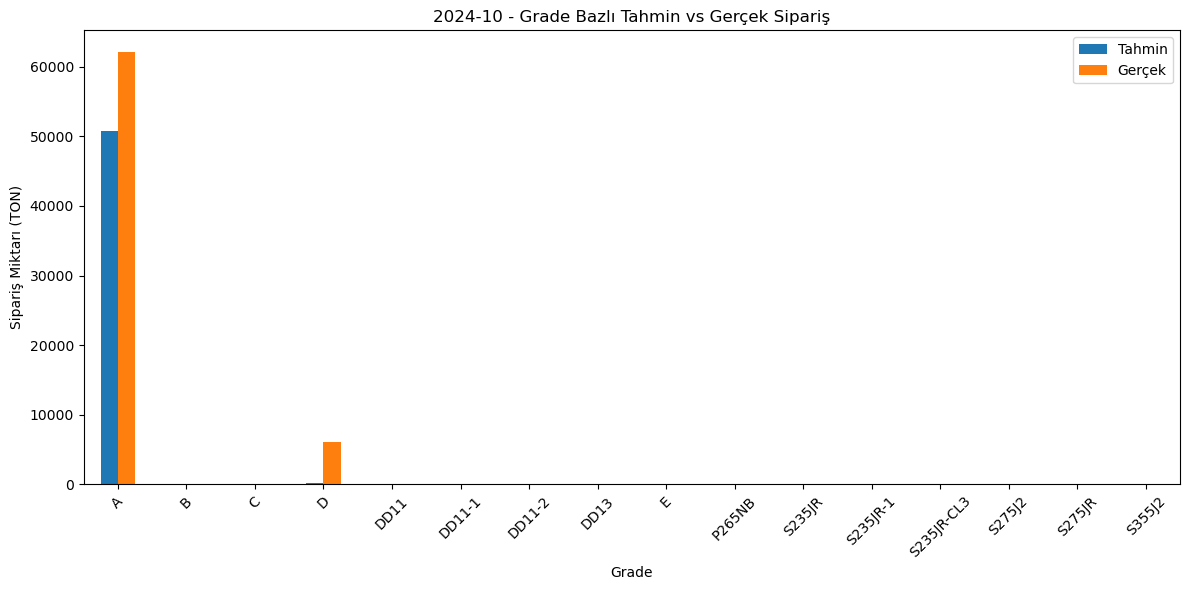

⏳ 2024-11 ayı için grafik hazırlanıyor...


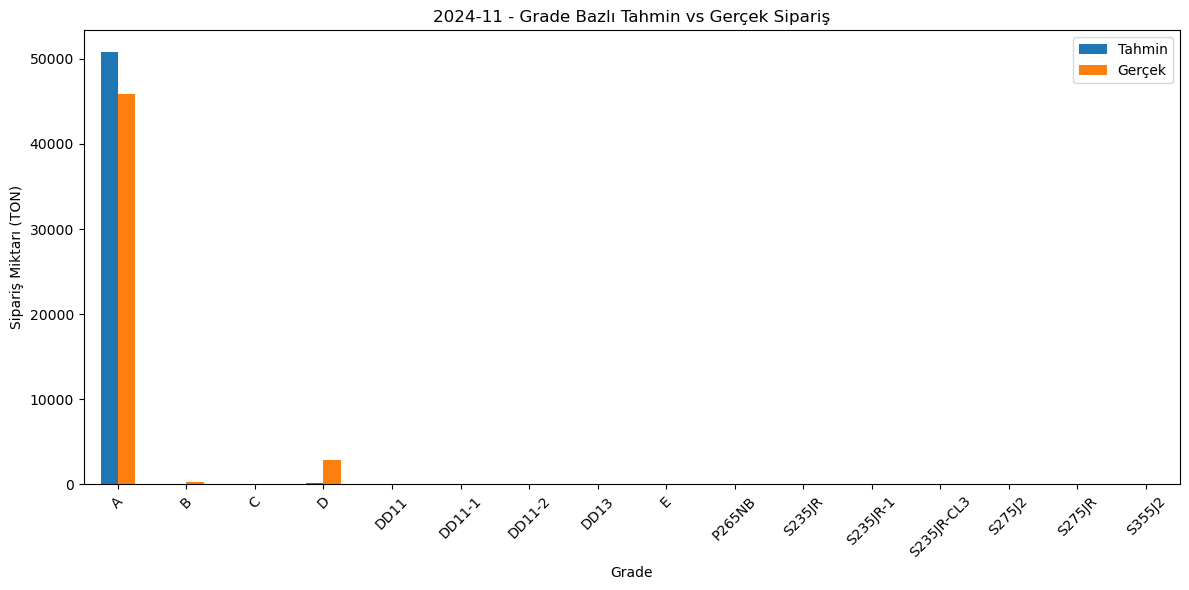

⏳ 2024-12 ayı için grafik hazırlanıyor...


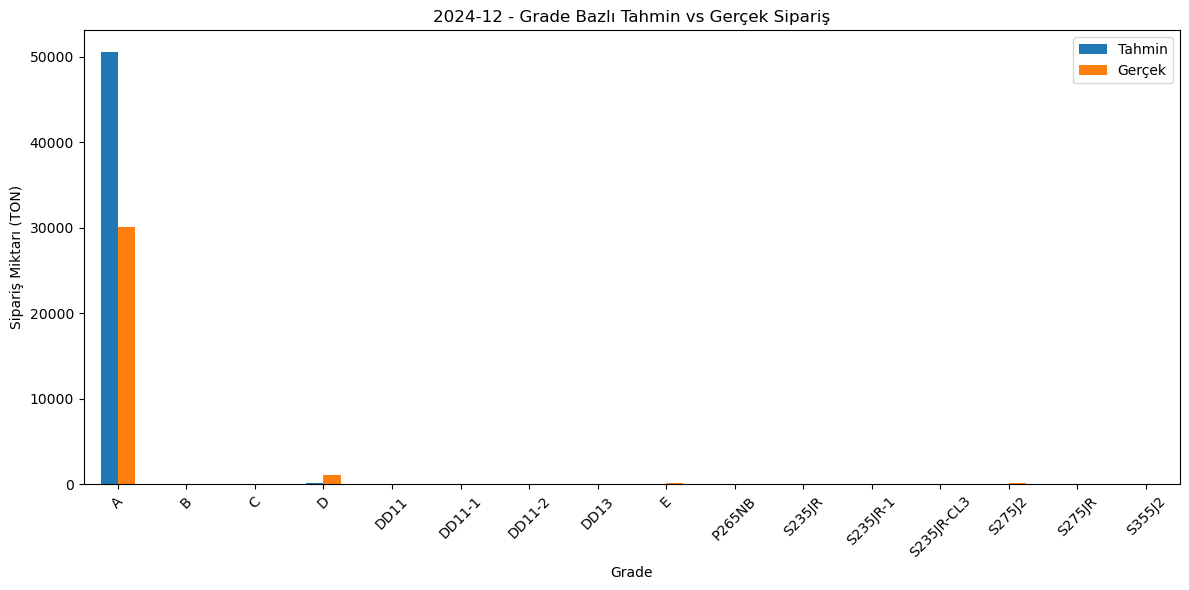

In [19]:
import matplotlib.pyplot as plt

# 🎯 Hedef aylar
target_months = ['2024-06','2024-07','2024-08', '2024-09', '2024-10','2024-11','2024-12']

for month in target_months:
    print(f"⏳ {month} ayı için grafik hazırlanıyor...")

    forecast_m = forecast_df[forecast_df['Month'] == month]
    actual_m = monthly_grade[monthly_grade['Month'] == month]

    # Verileri aynı forma sok
    forecast_m = forecast_m[['Grade', 'Forecast_TON']].set_index('Grade')
    actual_m = actual_m[['Grade', 'Sipariş Mik. (TON)']].set_index('Grade')

    # Ortak grade'leri al
    common_grades = forecast_m.index.intersection(actual_m.index)

    if len(common_grades) == 0:
        print(f"⚠️ {month} için hem tahmin hem gerçek veri yok.")
        continue

    compare_df = pd.DataFrame({
        'Forecast': forecast_m.loc[common_grades]['Forecast_TON'],
        'Actual': actual_m.loc[common_grades]['Sipariş Mik. (TON)']
    }).sort_index()

    # Bar chart
    compare_df.plot(kind='bar', figsize=(12,6))
    plt.title(f"{month} - Grade Bazlı Tahmin vs Gerçek Sipariş")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Tahmin", "Gerçek"])
    plt.tight_layout()
    plt.show()



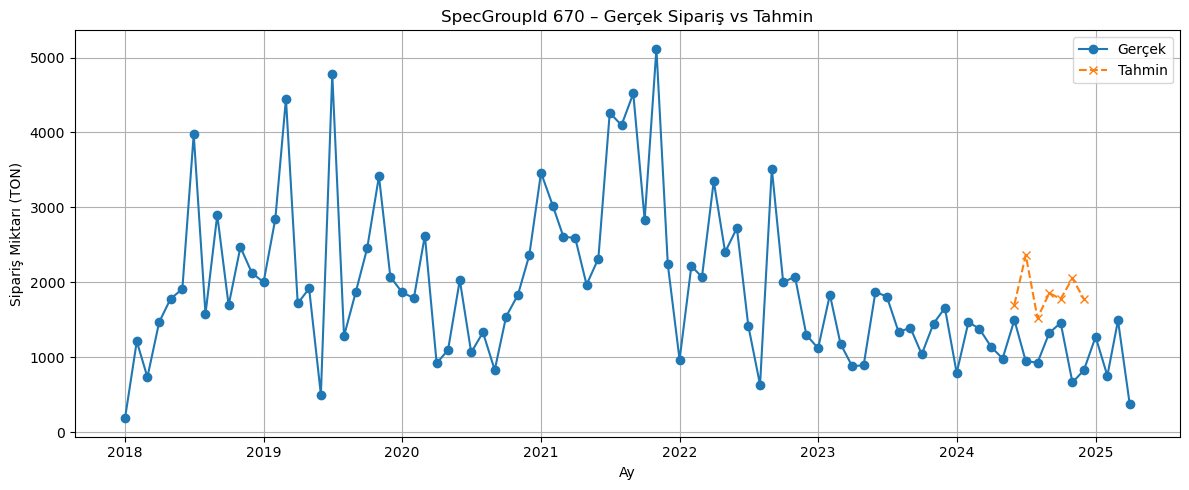

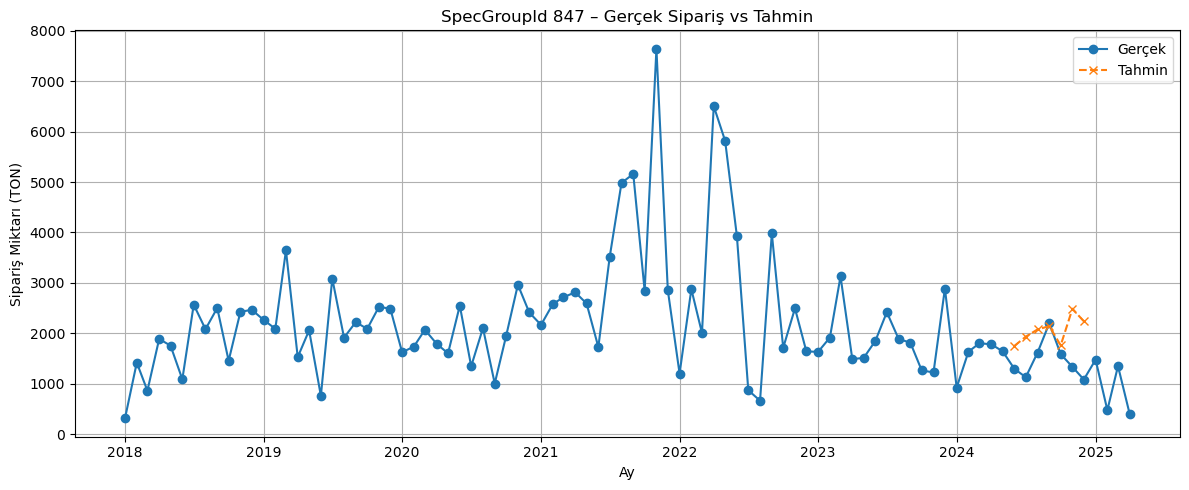

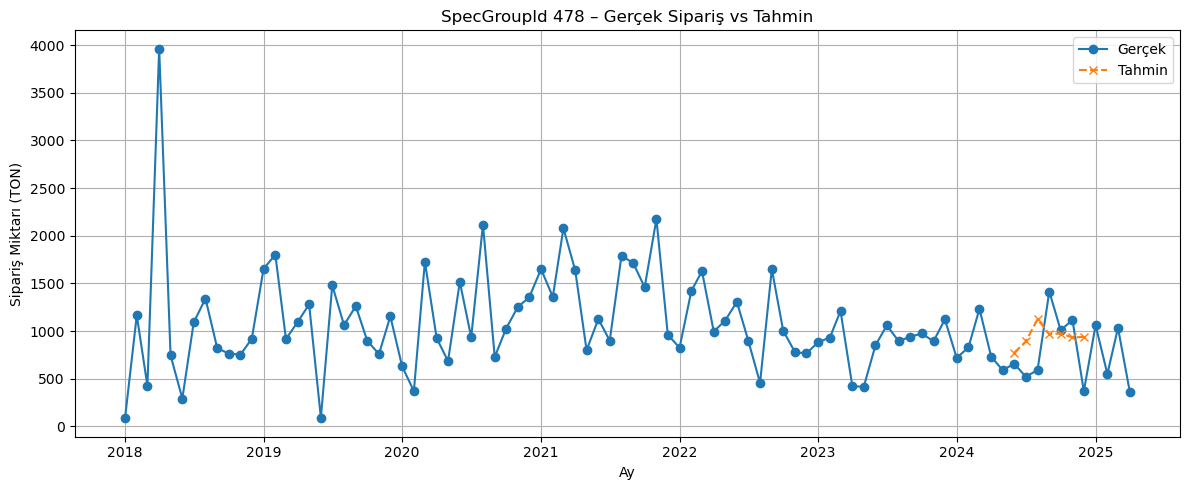

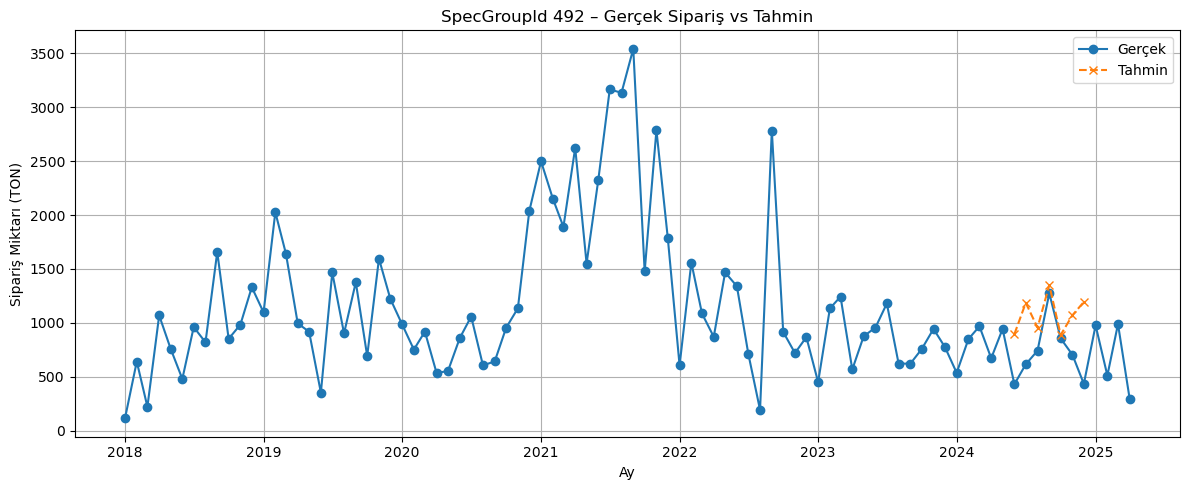

  SpecGroupId    MAE  MAPE (%)  sMAPE (%)  wMAPE (%)   RMSE
0         670 773.35     87.85      53.69      70.83 897.00
1         847 607.55     48.63      35.67      41.46 732.47
2         478 322.40     55.04      39.60      39.74 377.20
3         492 355.11     66.82      43.34      49.23 432.20


/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_40751/3461957568.py:70: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_40751/3461957568.py:70: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_40751/3461957568.py:70: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_40751/3461957568.py:70: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a futur

In [20]:
import matplotlib.pyplot as plt

# 🎯 Seçmek istediğin SpecGroupId’leri belirle
selected_spec_ids = [ '670', '847', '478','492']  # buraya ilgilendiğin ID'leri yaz

for spec_id in selected_spec_ids:
    # 🔹 Gerçek veriler (geçmiş)
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    # 🔹 Tahmin verileri (disaggregated)
    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

    
    # 🔗 İki veri setini birleştir
    merged = pd.concat([actual_series, forecast_series], axis=1)

    # 📈 Grafik
    plt.figure(figsize=(12, 5))
    plt.plot(merged.index, merged['Actual'], label='Gerçek', marker='o')
    plt.plot(merged.index, merged['Forecast'], label='Tahmin', linestyle='--', marker='x')
    plt.title(f"SpecGroupId {spec_id} – Gerçek Sipariş vs Tahmin")
    plt.xlabel("Ay")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# 🎯 Seçmek istediğin SpecGroupId’leri belirle
selected_spec_ids = ['670', '847','478','492']

# Sonuçları saklamak için boş DataFrame oluştur
metrics_df = pd.DataFrame(columns=['SpecGroupId', 'MAE', 'MAPE (%)', 'sMAPE (%)', 'wMAPE (%)', 'RMSE'])

for spec_id in selected_spec_ids:
    # 🔹 Gerçek veriler (geçmiş)
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    # 🔹 Tahmin verileri (disaggregated)
    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

    # 🔗 İki veri setini birleştir ve NaN değerleri kaldır
    merged = pd.concat([actual_series, forecast_series], axis=1).dropna()

    # 📌 Hata metriklerini hesapla
    mae = mean_absolute_error(merged['Actual'], merged['Forecast'])
    mape = mean_absolute_percentage_error(merged['Actual'], merged['Forecast']) * 100
    rmse = np.sqrt(mean_squared_error(merged['Actual'], merged['Forecast']))

    # sMAPE hesapla
    smape = 100 * np.mean(2 * np.abs(merged['Forecast'] - merged['Actual']) / (np.abs(merged['Actual']) + np.abs(merged['Forecast'])))

    # wMAPE hesapla
    wmape = 100 * np.sum(np.abs(merged['Forecast'] - merged['Actual'])) / np.sum(np.abs(merged['Actual']))

    # Sonuçları DataFrame'e ekle
    metrics_df = metrics_df.append({'SpecGroupId': spec_id,
                                    'MAE': mae,
                                    'MAPE (%)': mape,
                                    'sMAPE (%)': smape,
                                    'wMAPE (%)': wmape,
                                    'RMSE': rmse}, ignore_index=True)

# 📊 Sonuçları göster
print(metrics_df)



In [21]:
# Gerekli kütüphaneler
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Tüm SpecGroupId'ler için gerçek verileri hazırla
actual_series_all = df[['Month', 'SpecGroupId', 'Sipariş Mik. (TON)']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
actual_series_all.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

# Tüm SpecGroupId'ler için tahmin verilerini hazırla
forecast_series_all = disaggregated_df[['Month', 'SpecGroupId', 'Forecast_TON']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
forecast_series_all.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

# 🔗 Verileri birleştir
merged_all = pd.concat([actual_series_all, forecast_series_all], axis=1).dropna()

# Gerçek değeri 0.1'den büyük olanları filtrele
filtered_merged = merged_all[merged_all['Actual'] > 0.1]

print("total_count", len(merged_all))
print("filtered_count", len(filtered_merged))

# 🎯 Metrikleri hesapla
mae = mean_absolute_error(filtered_merged['Actual'], filtered_merged['Forecast'])
rmse = np.sqrt(mean_squared_error(filtered_merged['Actual'], filtered_merged['Forecast']))
mape = mean_absolute_percentage_error(filtered_merged['Actual'], filtered_merged['Forecast']) * 100
smape = 100 * np.mean(2 * np.abs(filtered_merged['Forecast'] - filtered_merged['Actual']) / 
                      (np.abs(filtered_merged['Forecast']) + np.abs(filtered_merged['Actual'])))
wmape = 100 * np.sum(np.abs(filtered_merged['Forecast'] - filtered_merged['Actual'])) / np.sum(np.abs(filtered_merged['Actual']))

# Sonuçları yazdır
print(f"Gerçek değeri 0.1'den büyük olanlar için:\n"
      f"MAE   : {mae:.2f}\n"
      f"RMSE  : {rmse:.2f}\n"
      f"MAPE  : {mape:.2f}%\n"
      f"sMAPE : {smape:.2f}%\n"
      f"wMAPE : {wmape:.2f}%")



total_count 9261
filtered_count 1291
Gerçek değeri 0.1'den büyük olanlar için:
MAE   : 186.98
RMSE  : 463.75
MAPE  : 104.66%
sMAPE : 100.10%
wMAPE : 62.63%


In [22]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   29
Model:                        SARIMAX   Log Likelihood                -173.587
Date:                Sat, 10 May 2025   AIC                            349.174
Time:                        22:22:48   BIC                            350.541
Sample:                    01-01-2022   HQIC                           349.602
                         - 05-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      9261.6986   1131.964      8.182      0.000    7043.090    1.15e+04
===================================================================================
Ljung-Box (L1) (Q):                   1.21   Jarque-Bera (JB):                69.96
Prob(Q):                              0.27   Prob(JB):                         0.00
Heteroskedasticity (H):               0.00   Skew:                             2.68
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Tüm SpecGroupId'ler için gerçek verileri hazırla
actual_series_all = df[['Month', 'SpecGroupId', 'Sipariş Mik. (TON)']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
actual_series_all.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

# Tüm SpecGroupId'ler için tahmin verilerini hazırla
forecast_series_all = disaggregated_df[['Month', 'SpecGroupId', 'Forecast_TON']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
forecast_series_all.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

# Verileri birleştir
merged_all = pd.concat([actual_series_all, forecast_series_all], axis=1).dropna()

# Gerçek değeri 0.1'den yüksek olanları filtrele
filtered_merged = merged_all[merged_all['Actual'] > 0.1]

print("total_count", len(merged_all))
print("filtered_count", len(filtered_merged))

# SARIMAX Modelini çalıştır
model = SARIMAX(filtered_merged['Actual'], order=(1,0,0))
result = model.fit()

# R² Hesapla
predictions = result.fittedvalues
r2 = r2_score(filtered_merged['Actual'], predictions)

# Parametrelerin anlamlılık tablosunu hazırla
params_summary = pd.DataFrame({
    'Coefficient': result.params,
    'Std_Error': result.bse,
    'p-value': result.pvalues,
    'Significant': result.pvalues < 0.05
})

# Sonuçları yazdır
print(f"R²: {r2:.4f}")
print("\nParametrelerin Anlamlılık Tablosu:\n", params_summary)

total_count 9261
filtered_count 1291
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.14459D+00    |proj g|=  1.02608D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    2      1      3      1     0     0   2.125D-05   8.145D+00
  F =   8.1445909806127528     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
R²: -0.1213

Parametrelerin Anlamlılık Tablosu:
         Coefficient  Std_Error  p-value  Significant
ar.L1          0.14       0.02     0.00         True
si

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
 This problem is unconstrained.


In [24]:
import pandas as pd

# Gerçek verileri hazırla
actual_series_all = df[['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']]\
    .groupby(['Month', 'SpecGroupId', 'Grade'])\
    .sum().reset_index()

actual_series_all.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

# Tahmin verilerini hazırla
forecast_series_all = disaggregated_df[['Month', 'SpecGroupId', 'Forecast_TON']]\
    .groupby(['Month', 'SpecGroupId'])\
    .sum().reset_index()

forecast_series_all.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

# Gerçek ve Tahmin verilerini birleştir
merged_all = pd.merge(actual_series_all, forecast_series_all, 
                      on=['Month', 'SpecGroupId'], 
                      how='left').dropna()

# Sonucu Excel'e kaydet
#merged_all.to_excel('actual_forecast_with_grade_month_specgroup.xlsx', index=False)



⏳ 2019-01 ayı için grafik hazırlanıyor...
⚠️ 2019-01 için hem tahmin hem gerçek veri yok.
⏳ 2022-07 ayı için grafik hazırlanıyor...


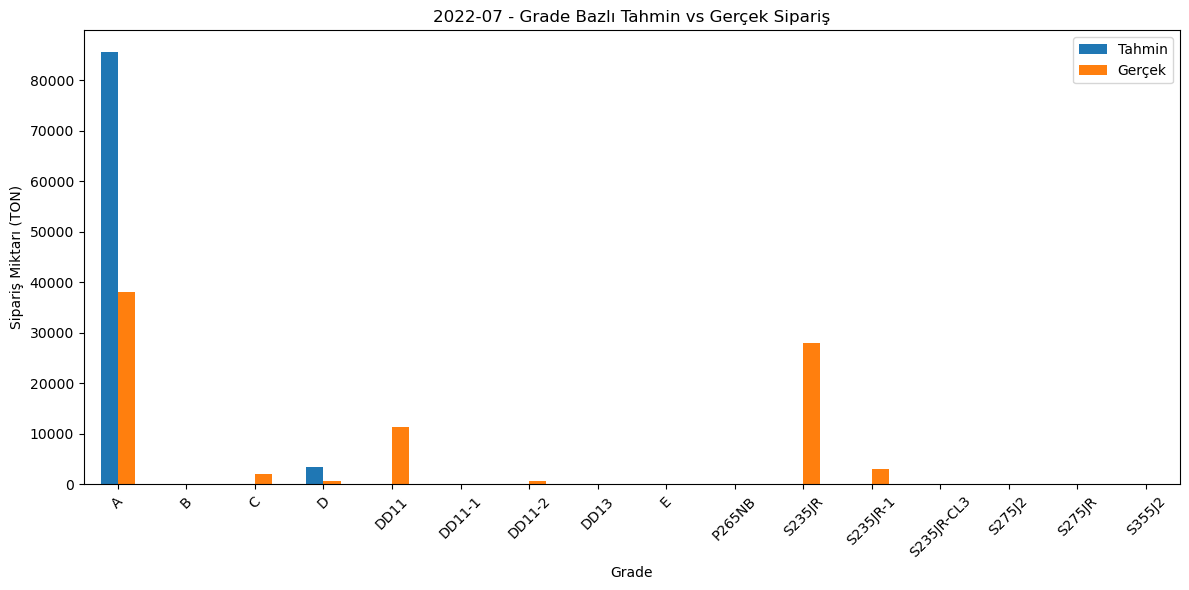

⏳ 2023-03 ayı için grafik hazırlanıyor...


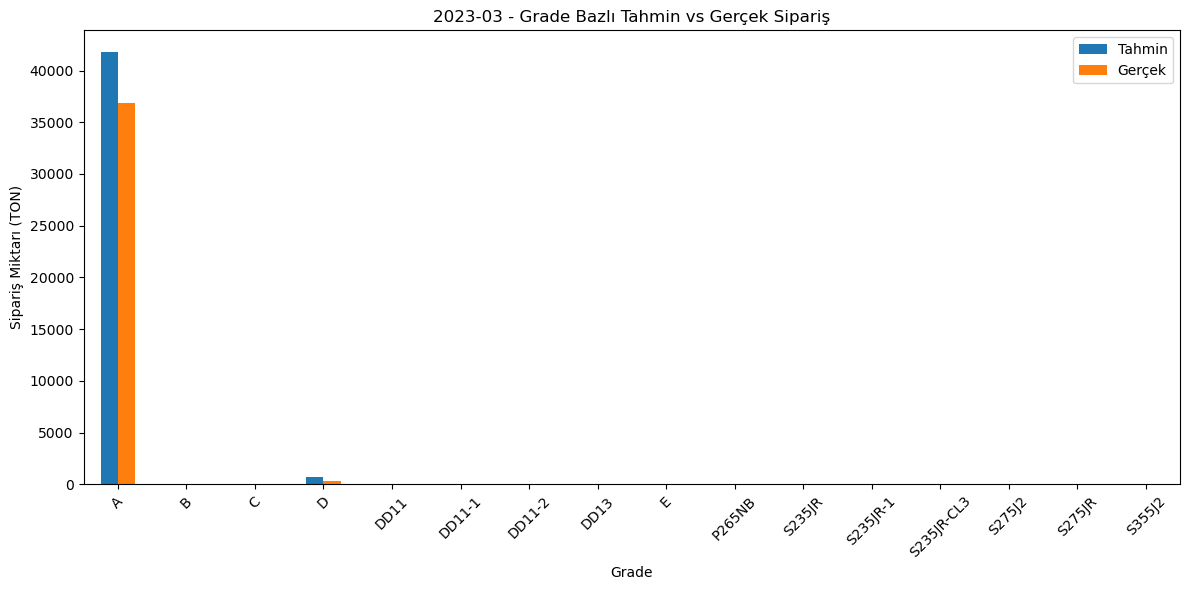

In [25]:
#OVERFIT TEST

import matplotlib.pyplot as plt

# 🎯 Hedef aylar
target_months = ['2019-01', '2022-07', '2023-03']

for month in target_months:
    print(f"⏳ {month} ayı için grafik hazırlanıyor...")

    forecast_m = train_forecast_df[train_forecast_df['Month'] == month]
    actual_m = monthly_grade[monthly_grade['Month'] == month]

    # Verileri aynı forma sok
    forecast_m = forecast_m[['Grade', 'Forecast_TON']].set_index('Grade')
    actual_m = actual_m[['Grade', 'Sipariş Mik. (TON)']].set_index('Grade')

    # Ortak grade'leri al
    common_grades = forecast_m.index.intersection(actual_m.index)

    if len(common_grades) == 0:
        print(f"⚠️ {month} için hem tahmin hem gerçek veri yok.")
        continue

    compare_df = pd.DataFrame({
        'Forecast': forecast_m.loc[common_grades]['Forecast_TON'],
        'Actual': actual_m.loc[common_grades]['Sipariş Mik. (TON)']
    }).sort_index()

    # Bar chart
    compare_df.plot(kind='bar', figsize=(12,6))
    plt.title(f"{month} - Grade Bazlı Tahmin vs Gerçek Sipariş")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Tahmin", "Gerçek"])
    plt.tight_layout()
    plt.show()


In [26]:
import matplotlib.pyplot as plt

# 🎯 Seçmek istediğin SpecGroupId’leri belirle
selected_spec_ids = [ '670', '847','478','492']  # buraya ilgilendiğin ID'leri yaz
for spec_id in selected_spec_ids:
        # 🔹 Gerçek veriler (geçmiş)
        actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
        actual_series = actual_series.groupby('Month').sum().sort_index()
        actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

        # 🔹 Tahmin verileri (disaggregated)
        forecast_series = disaggregated_forecast_df[disaggregated_forecast_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
        forecast_series = forecast_series.groupby('Month').sum().sort_index()
        forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)


        # 🔗 İki veri setini birleştir
        merged = pd.concat([actual_series, forecast_series], axis=1)

        # 📈 Grafik
        plt.figure(figsize=(12, 5))
        plt.plot(merged.index, merged['Actual'], label='Gerçek', marker='o')
        plt.plot(merged.index, merged['Forecast'], label='Tahmin', linestyle='--', marker='x')
        plt.title(f"SpecGroupId {spec_id} – Gerçek Sipariş vs Tahmin")
        plt.xlabel("Ay")
        plt.ylabel("Sipariş Miktarı (TON)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

KeyError: 'SpecGroupId'

In [27]:
#QUARTERLY

In [28]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:,.2f}'.format

# 1. Veri yükleme
df = pd.read_excel('preprocessedBelgeler/zero_filled_forecastData_altLimit100_son3_byGrup.xlsx')
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# 2. Aylık veriyi çeyreklik veriye çevirme
df['Quarter'] = df['Month'].dt.to_period('Q').dt.to_timestamp()
quarterly_grade = df.groupby(['Quarter', 'Grade'])['Sipariş Mik. (TON)'].sum().reset_index()
grade_list = quarterly_grade['Grade'].unique()

# Boş dataframe’ler
forecast_df = pd.DataFrame()
train_forecast_df = pd.DataFrame()
disaggregated_df = pd.DataFrame()
disaggregated_forecast_df = pd.DataFrame()
mae_list = []
mape_list = []

# 3. Her grade için SARIMAX modeli ile quarterly tahmin
for grade in grade_list:
    grade_data = quarterly_grade[quarterly_grade['Grade'] == grade].set_index('Quarter')
    grade_data = grade_data.loc['2022-03-31':'2024-06-30']  # Quarterly tarih aralığı

    grade_ts = grade_data['Sipariş Mik. (TON)'].asfreq('QS').fillna(0)  # QS = Quarter Start

    if grade_ts.std() < 1e-3 or grade_ts.sum() == 0:
        print(f"'{grade}' atlandı çünkü zaman serisi sabit veya boş.")
        continue

    try:
        model = SARIMAX(grade_ts, order=(1,0,0), seasonal_order=(0,0,0,0))
        results = model.fit(disp=False)
    except Exception as e:
        print(f"{grade} için model kurulamadı: {e}")
        continue

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(grade_ts, lags=4, ax=ax[0])
    ax[0].set_title(f"{grade} - ACF (Quarterly)")

    plot_pacf(grade_ts, lags=4, ax=ax[1], method='ywm')
    ax[1].set_title(f"{grade} - PACF (Quarterly)")
    plt.tight_layout()
    plt.show()

    forecast = results.get_forecast(steps=4)
    forecast_values = forecast.predicted_mean
    forecast_index = forecast_values.index

    train_forecast = results.predict(start=grade_ts.index[0], end=grade_ts.index[-1])
    train_forecast_index = train_forecast.index

    full_grade_data = quarterly_grade[quarterly_grade['Grade'] == grade].set_index('Quarter')
    test_data = full_grade_data.loc['2024-07-30':'2024-12-30']['Sipariş Mik. (TON)'].asfreq('QS').fillna(0)
    common_quarters = test_data.index.intersection(forecast_index)

    if len(common_quarters) > 0:
        actual = test_data.loc[common_quarters]
        predicted = forecast_values.loc[common_quarters]

        mae = mean_absolute_error(actual, predicted)
        mape = mean_absolute_percentage_error(actual, predicted)

        mae_list.append({'Grade': grade, 'MAE_Model': mae})
        mape_list.append({'Grade': grade, 'MAPE_Model': mape})

        print(f"\n📈 Grade '{grade}' için MODEL tahmini:")
        print(f"Gerçek: {actual.values}, Tahmin: {predicted.values}")
        print(f"MAE: {mae:.2f}, MAPE: {mape:.2%}")

    # Forecast ekle
    temp_forecast = pd.DataFrame({
        'Quarter': forecast_index,
        'Grade': grade,
        'Forecast_TON': forecast_values.values
    })
    forecast_df = pd.concat([forecast_df, temp_forecast], ignore_index=True)

    temp_forecast_train = pd.DataFrame({
        'Quarter': train_forecast_index,
        'Grade': grade,
        'Forecast_TON': train_forecast.values
    })
    train_forecast_df = pd.concat([train_forecast_df, temp_forecast_train], ignore_index=True)

    # Disaggregation
    for quarter in forecast_index:
        quarter_end_month = quarter + pd.DateOffset(months=2)
        past_months = df[(df['Grade'] == grade) & (df['Month'].dt.month == quarter_end_month.month)]
        past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
        total = past_months_total.sum()

        if total == 0:
            print(f"{grade} için {quarter.strftime('%Y-Q%q')} çeyreğinde ay bazlı veri bulunamadı. Tüm geçmiş alınacak.")
            past_months = df[df['Grade'] == grade]
            past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            total = past_months_total.sum()

        if total == 0:
            print(f"{grade} için {quarter.strftime('%Y-Q%q')} çeyreğinde hiç veri bulunamadı.")
            continue

        proportions = past_months_total / total
        disagg = proportions * forecast_values[quarter]

        for spec_id, miktar in disagg.items():
            disaggregated_df = pd.concat([disaggregated_df, pd.DataFrame({
                'Quarter': [quarter],
                'Grade': [grade],
                'SpecGroupId': [spec_id],
                'Forecast_TON': [miktar]
            })])

        actual_df = df[(df['Month'] >= quarter) & 
                       (df['Month'] < quarter + pd.DateOffset(months=3)) &
                       (df['Grade'] == grade)]
        actual_agg = actual_df.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()

        forecast_agg = disaggregated_df[
            (disaggregated_df['Quarter'] == quarter) &
            (disaggregated_df['Grade'] == grade)
        ].groupby('SpecGroupId')['Forecast_TON'].sum()

        common_index = actual_agg.index.intersection(forecast_agg.index)
        if len(common_index) > 0:
            actual_vals = actual_agg.loc[common_index]
            pred_vals = forecast_agg.loc[common_index]

            for spec_id in common_index:
                disagg_metrics = {
                    'Grade': grade,
                    'Quarter': quarter,
                    'SpecGroupId': spec_id,
                    'MAE_Disagg': abs(actual_vals[spec_id] - pred_vals[spec_id]),
                    'MAPE_Disagg': abs((actual_vals[spec_id] - pred_vals[spec_id]) / actual_vals[spec_id]) if actual_vals[spec_id] != 0 else np.nan
                }
                mae_list.append(disagg_metrics)

# Export
disaggregated_df.to_excel("quarterly_disaggregated_forecast.xlsx", index=False)


FileNotFoundError: [Errno 2] No such file or directory: 'preprocessedBelgeler/zero_filled_forecastData_altLimit100_son3_byGrup.xlsx'

In [29]:
import matplotlib.pyplot as plt

# 🎯 Hedef çeyrekler
target_quarters = ['2024Q3', '2024Q4']

for quarter_str in target_quarters:
    quarter = pd.Period(quarter_str, freq='Q').to_timestamp()
    print(f"⏳ {quarter_str} çeyreği için grafik hazırlanıyor...")

    forecast_q = forecast_df[forecast_df['Quarter'] == quarter]
    actual_q = quarterly_grade[quarterly_grade['Quarter'] == quarter]

    forecast_q = forecast_q[['Grade', 'Forecast_TON']].set_index('Grade')
    actual_q = actual_q[['Grade', 'Sipariş Mik. (TON)']].set_index('Grade')

    common_grades = forecast_q.index.intersection(actual_q.index)

    if len(common_grades) == 0:
        print(f"⚠️ {quarter_str} için hem tahmin hem gerçek veri yok.")
        continue

    compare_df = pd.DataFrame({
        'Forecast': forecast_q.loc[common_grades]['Forecast_TON'],
        'Actual': actual_q.loc[common_grades]['Sipariş Mik. (TON)']
    }).sort_index()

    compare_df.plot(kind='bar', figsize=(12,6))
    plt.title(f"{quarter_str} - Grade Bazlı Tahmin vs Gerçek Sipariş")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Tahmin", "Gerçek"])
    plt.tight_layout()
    plt.show()


⏳ 2024Q3 çeyreği için grafik hazırlanıyor...


KeyError: 'Quarter'

In [30]:
from sklearn.metrics import mean_squared_error

# 🎯 Grade bazlı performans metriklerini hesapla (quarterly)
grade_metrics = []

for grade in forecast_df['Grade'].unique():
    # Tahmin edilen veriler
    pred_series = forecast_df[forecast_df['Grade'] == grade].set_index('Quarter')['Forecast_TON']

    # Gerçek veriler
    actual_series = quarterly_grade[quarterly_grade['Grade'] == grade].set_index('Quarter')['Sipariş Mik. (TON)']

    # Ortak çeyrekler
    common_quarters = pred_series.index.intersection(actual_series.index)

    if len(common_quarters) == 0:
        continue

    y_true = actual_series.loc[common_quarters]
    y_pred = pred_series.loc[common_quarters]

    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

    grade_metrics.append({
        'Grade': grade,
        'MAE': mae,
        'MAPE (%)': mape,
        'sMAPE (%)': smape,
        'wMAPE (%)': wmape,
        'RMSE': rmse
    })

# 🎉 Sonuçları tablo olarak göster
grade_metrics_df = pd.DataFrame(grade_metrics)
print("\n📊 Grade Bazlı Quarterly Tahmin Performansı:")
print(grade_metrics_df)

# Excel'e kaydetmek istersen:
# grade_metrics_df.to_excel("quarterly_grade_metrics_summary.xlsx", index=False)


KeyError: "None of ['Quarter'] are in the columns"